**Table of contents**<a id='toc0_'></a>    
- [文件说明（File descriptions）](#toc1_)    
- [数据字段（Data fields）](#toc2_)    
- [导入库](#toc3_)    
- [EDA(数据探索性分析)](#toc4_)    
- [工具函数](#toc5_)    
- [数据预处理](#toc6_)    
- [特征工程](#toc7_)    
- [贝叶斯优化参数空间](#toc8_)    
- [合成数据生成](#toc9_)    
- [5 折交叉验证训练](#toc10_)    
- [模型融合](#toc11_)    
  - [加权融合（权重按 OOF F1 的幂次）](#toc11_1_)    
  - [Stacking（Logistic/RandomForest 选最佳）](#toc11_2_)    
- [提交文件](#toc12_)    
- [结果可视化](#toc13_)    

<!-- vscode-jupyter-toc-config
    numbering=false
    anchor=true
    flat=false
    minLevel=1
    maxLevel=6
    /vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[文件说明（File descriptions）](#toc0_)
- train.csv - 训练集
- test.csv - 测试集
- sampleSubmission.csv - 格式正确的提交文件示例


# <a id='toc2_'></a>[数据字段（Data fields）](#toc0_)
- Home Ownership - 住房所有权（房屋拥有情况）
- Annual Income - 年收入
- Years in current job - 当前工作年限
- Tax Liens - 税收留置权（税务扣押权）
- Number of Open Accounts - 未结清账户数量（已开立账户数量）
- Years of Credit History - 信用历史年限
- Maximum Open Credit - 最高未结清信贷额度（曾向客户开放的最高信贷金额）
- Number of Credit Problems - 信用问题次数
- Months since last delinquent - 上次逾期至今的月数
- Bankruptcies - 破产次数
- Purpose - 贷款用途
- Term - 贷款期限
- Current Loan Amount - 当前贷款金额（客户仍需偿还的贷款余额）
- Current Credit Balance - 当前信用余额（客户可从信贷账户中使用的金额）
- Monthly Debt - 月债务金额（每月需偿还的债务）
- Credit Score - 信用评分
- Credit Default - 信贷违约情况（0 - 按时还清，1 - 逾期）

# <a id='toc3_'></a>[导入库](#toc0_)

In [2]:
# ==========================================
# 信用违约预测（LightGBM + XGBoost + CatBoost）
# 1. 自动贝叶斯优化（LGB/XGB/CAT）
# 2. 数据合成
# 3. 五折 StratifiedKFold 训练
# 4. 加权融合 + Stacking
# 5. SHAP 解释性 + ROC/PR 可视化
# ==========================================
import warnings, os, random, gc
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# 设置全局字体，支持中文显示
# ----------------------------
# 解决中文字体 & findfont 报错
# ----------------------------
import matplotlib as mpl

# 让 matplotlib 走 “sans-serif 字体族”
mpl.rcParams["font.family"] = "sans-serif"

# 让中文字体排在最前（有哪个用哪个）
mpl.rcParams["font.sans-serif"] = [
    "SimHei",                # 万一你后来自己装了 SimHei
    "Noto Sans CJK SC",      # 你装了 fonts-noto-cjk 后通常就有
    "WenQuanYi Zen Hei",     # fonts-wqy-zenhei
    "WenQuanYi Micro Hei",   # fonts-wqy-microhei
    "Microsoft YaHei",
    "Arial Unicode MS",
    "DejaVu Sans",           # 最后兜底（不保证中文）
]

# 负号正常显示
mpl.rcParams["axes.unicode_minus"] = False


from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve,
    RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier


from sklearn.neighbors import NearestNeighbors
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN

from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

import lightgbm as lgb
import xgboost as xgb
import catboost as cb
import shap
shap.initjs()

In [3]:
TRAIN_PATH = "train.csv"
TEST_PATH = "test.csv"
SAMPLE_SUB_PATH = "sample_submission.csv"
SUBMISSION_OUT = "submission.csv"

# <a id='toc4_'></a>[EDA(数据探索性分析)](#toc0_)

1. 查看表格数据全貌​
2. 分析数据特征类型与缺失值情况​
3. 探究类别特征与目标特征的关联关系​
4. 剖析数值特征的数据分布特征

In [4]:
train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)
sample_sub = pd.read_csv(SAMPLE_SUB_PATH)
display(train.head())

,Home Ownership,Annual Income,Years in current job,Tax Liens,Number of Open Accounts,Years of Credit History,Maximum Open Credit,Number of Credit Problems,Months since last delinquent,Bankruptcies,Purpose,Term,Current Loan Amount,Current Credit Balance,Monthly Debt,Credit Score,Credit Default
0,Own Home,482087.0,NaN,0.0,11.0,26.3,685960.0,1.0,NaN,1.0,debt consolidation,Short Term,99999999.0,47386.0,7914.0,749.0,0
1,Own Home,1025487.0,10+ years,0.0,15.0,15.3,1181730.0,0.0,NaN,0.0,debt consolidation,Long Term,264968.0,394972.0,18373.0,737.0,1
2,Home Mortgage,751412.0,8 years,0.0,11.0,35.0,1182434.0,0.0,NaN,0.0,debt consolidation,Short Term,99999999.0,308389.0,13651.0,742.0,0
3,Own Home,805068.0,6 years,0.0,8.0,22.5,147400.0,1.0,NaN,1.0,debt consolidation,Short Term,121396.0,95855.0,11338.0,694.0,0
4,Rent,776264.0,8 years,0.0,13.0,13.6,385836.0,1.0,NaN,0.0,debt consolidation,Short Term,125840.0,93309.0,7180.0,719.0,0


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Home Ownership                7500 non-null   object 
 1   Annual Income                 5943 non-null   float64
 2   Years in current job          7129 non-null   object 
 3   Tax Liens                     7500 non-null   float64
 4   Number of Open Accounts       7500 non-null   float64
 5   Years of Credit History       7500 non-null   float64
 6   Maximum Open Credit           7500 non-null   float64
 7   Number of Credit Problems     7500 non-null   float64
 8   Months since last delinquent  3419 non-null   float64
 9   Bankruptcies                  7486 non-null   float64
 10  Purpose                       7500 non-null   object 
 11  Term                          7500 non-null   object 
 12  Current Loan Amount           7500 non-null   float64
 13  Cur

In [6]:
print(train.isnull().sum()) #checking for total null values

Home Ownership                     0
Annual Income                   1557
Years in current job             371
Tax Liens                          0
Number of Open Accounts            0
Years of Credit History            0
Maximum Open Credit                0
Number of Credit Problems          0
Months since last delinquent    4081
Bankruptcies                      14
Purpose                            0
Term                               0
Current Loan Amount                0
Current Credit Balance             0
Monthly Debt                       0
Credit Score                    1557
Credit Default                     0
dtype: int64


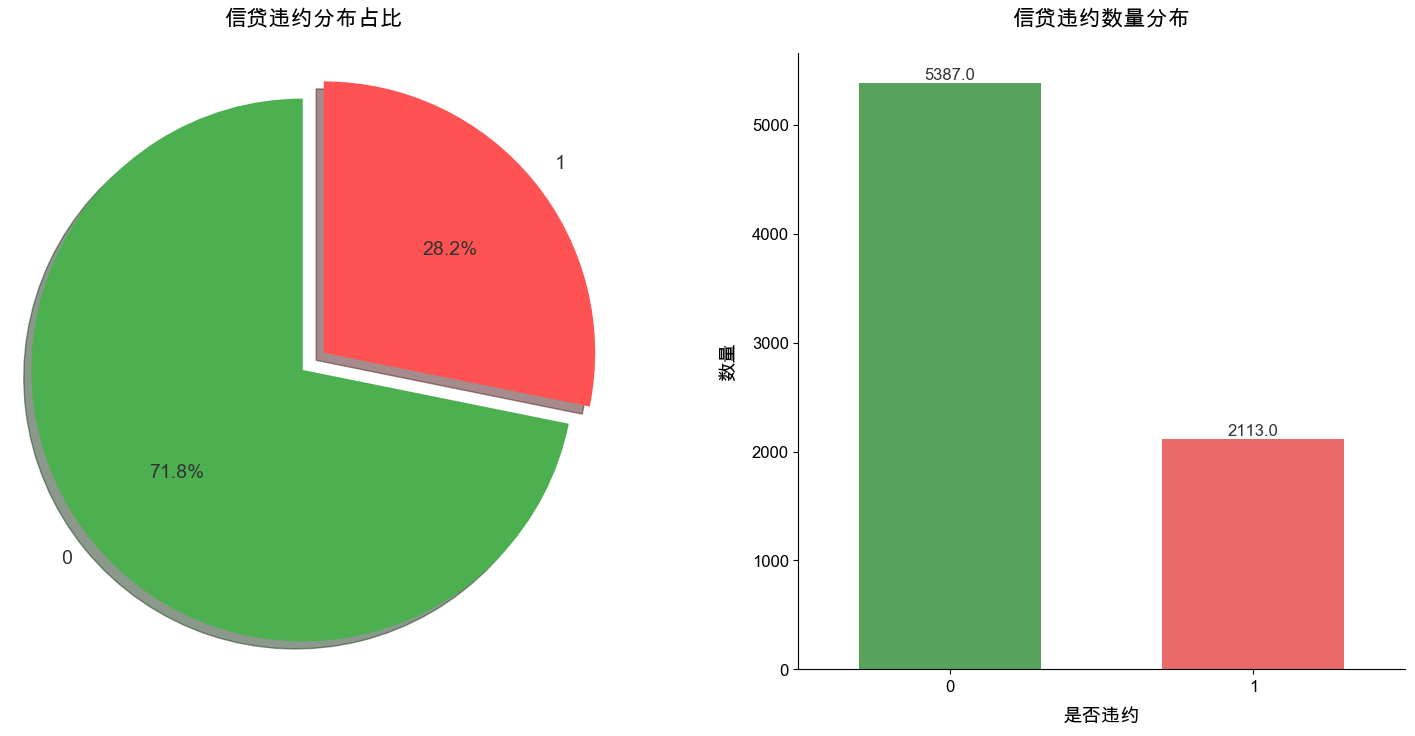

In [7]:
# 创建画布和子图，调整间距
f, ax = plt.subplots(1, 2, figsize=(18, 8))
plt.subplots_adjust(wspace=0.3)  # 调整子图间距

# 定义配色方案（柔和且对比明显）
colors = ['#4CAF50', '#FF5252']  # 绿色和红色（适合二分类对比）

# 饼图优化
train['Credit Default'].value_counts().plot.pie(
    explode=[0, 0.1],
    autopct='%1.1f%%',
    ax=ax[0],
    shadow=True,
    colors=colors,
    startangle=90,  # 旋转90度，让饼图更平衡
    textprops={'fontsize': 14, 'color': '#333333'}  # 百分比文字样式
)
ax[0].set_title('信贷违约分布占比', fontsize=16, pad=20, fontweight='bold')  # 标题样式优化
ax[0].set_ylabel('')  # 去除y轴标签
ax[0].axis('equal')  # 保证饼图是正圆形

# 柱状图优化
sns.countplot(
    x='Credit Default',
    data=train,
    ax=ax[1],
    palette=colors,
    width=0.6  # 调整柱宽
)
ax[1].set_title('信贷违约数量分布', fontsize=16, pad=20, fontweight='bold')
ax[1].set_xlabel('是否违约', fontsize=14, labelpad=10)  # x轴标签优化
ax[1].set_ylabel('数量', fontsize=14, labelpad=10)

# 为柱状图添加数值标签
for p in ax[1].patches:
    height = p.get_height()
    ax[1].text(
        p.get_x() + p.get_width() / 2.,  # x坐标
        height + 5,  # y坐标（在柱顶上方）
        f'{height}',  # 显示的数值
        ha='center', va='bottom', fontsize=12, color='#333333'
    )

# 美化坐标轴刻度
ax[1].tick_params(axis='both', which='major', labelsize=12)

# 去除顶部和右侧边框
for spine in ax[1].spines.values():
    if spine.spine_type in ['top', 'right']:
        spine.set_visible(False)

plt.show()

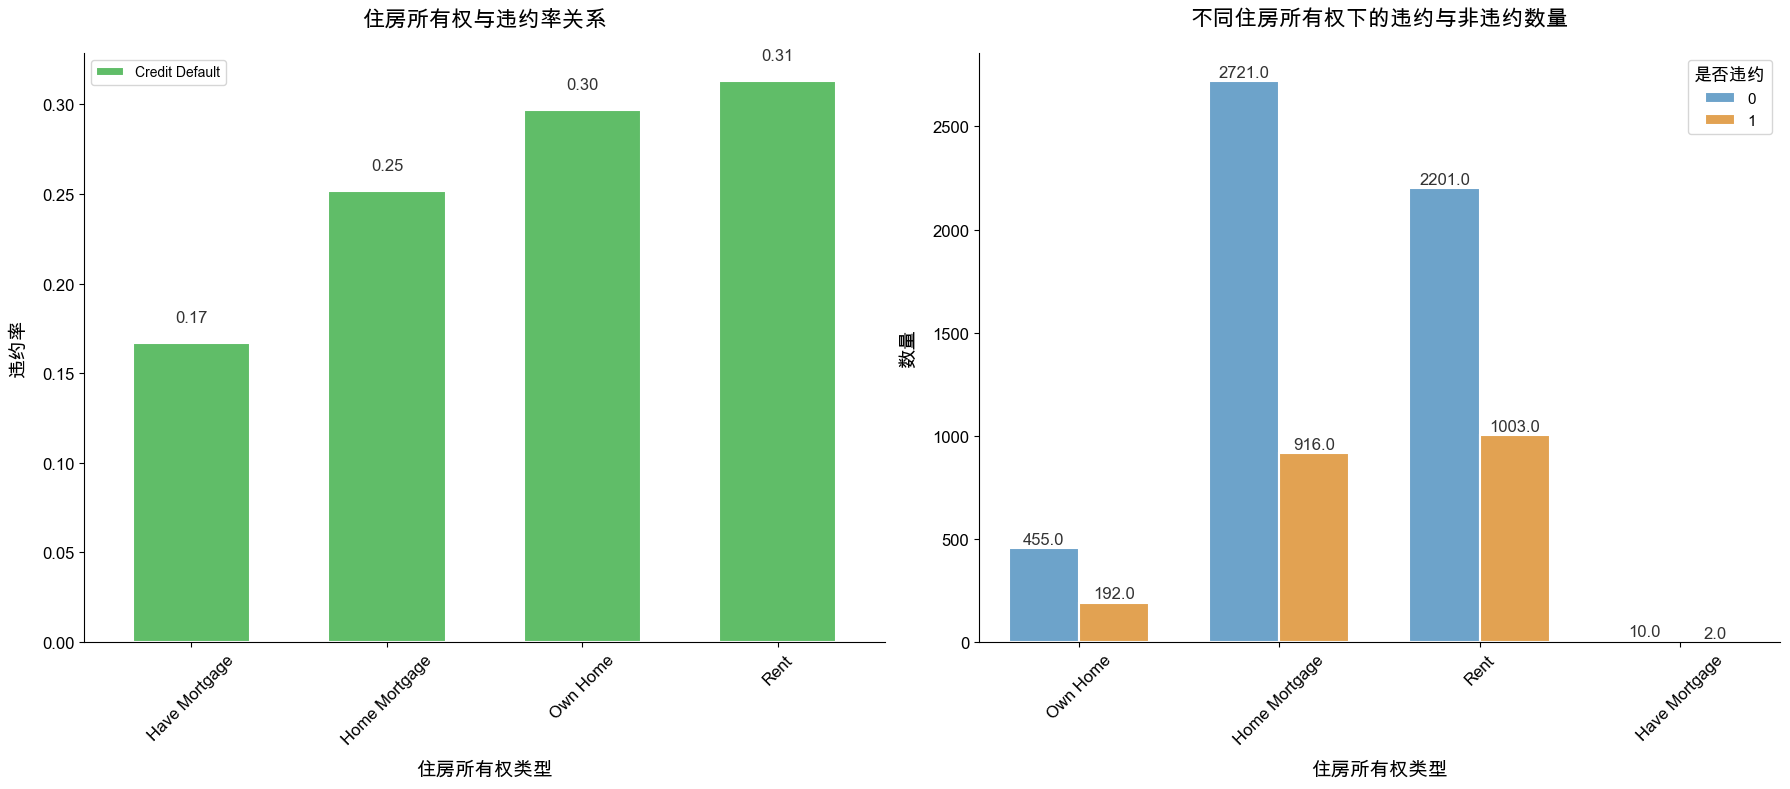

In [8]:
# 创建画布，调整子图间距
f, ax = plt.subplots(1, 2, figsize=(18, 8))
plt.subplots_adjust(wspace=0.25)  # 控制两图间距，避免拥挤

# 定义统一配色（柔和且专业）
bar_colors = ['#5DA5DA', '#FAA43A']  # 蓝色系和橙色系，对比清晰不刺眼
mean_color = '#60BD68'  # 均值柱状图用绿色，突出趋势

# 左侧：均值柱状图优化
home_default_mean = train[['Home Ownership', 'Credit Default']].groupby(['Home Ownership']).mean()
home_default_mean.plot.bar(
    ax=ax[0],
    color=mean_color,
    width=0.6,  # 适中的柱宽，避免过宽或过窄
    edgecolor='white',  # 白色边框增强立体感
    linewidth=1.5
)
ax[0].set_title('住房所有权与违约率关系', fontsize=16, pad=20, fontweight='bold')
ax[0].set_xlabel('住房所有权类型', fontsize=14, labelpad=10)
ax[0].set_ylabel('违约率', fontsize=14, labelpad=10)
ax[0].tick_params(axis='x', labelsize=12, rotation=45)  # x轴标签轻微旋转，避免重叠
ax[0].tick_params(axis='y', labelsize=12)

# 为均值图添加数值标签（保留两位小数）
for p in ax[0].patches:
    ax[0].text(
        p.get_x() + p.get_width()/2, p.get_height() + 0.01,
        f'{p.get_height():.2f}',  # 显示违约率数值
        ha='center', va='bottom', fontsize=12, color='#333333'
    )

# 去除左侧图顶部和右侧边框，更简洁
for spine in ax[0].spines.values():
    if spine.spine_type in ['top', 'right']:
        spine.set_visible(False)

# 右侧：分组计数图优化
sns.countplot(
    x='Home Ownership',
    hue='Credit Default',
    data=train,
    ax=ax[1],
    palette=bar_colors,
    width=0.7,
    edgecolor='white',
    linewidth=1.5
)
ax[1].set_title('不同住房所有权下的违约与非违约数量', fontsize=16, pad=20, fontweight='bold')
ax[1].set_xlabel('住房所有权类型', fontsize=14, labelpad=10)
ax[1].set_ylabel('数量', fontsize=14, labelpad=10)
ax[1].tick_params(axis='x', labelsize=12, rotation=45)  # 标签旋转角度适中，兼顾可读性和美观
ax[1].tick_params(axis='y', labelsize=12)

# 为分组计数图添加数值标签
for p in ax[1].patches:
    height = p.get_height()
    if height > 0:  # 只显示有数值的标签
        ax[1].text(
            p.get_x() + p.get_width()/2, height + 5,
            f'{height}',
            ha='center', va='bottom', fontsize=12, color='#333333'
        )

# 优化右侧图图例
ax[1].legend(title='是否违约', title_fontsize=13, fontsize=11, loc='upper right')
# 去除右侧图顶部和右侧边框
for spine in ax[1].spines.values():
    if spine.spine_type in ['top', 'right']:
        spine.set_visible(False)

# 整体布局调整，避免标签被截断
plt.tight_layout()
plt.show()

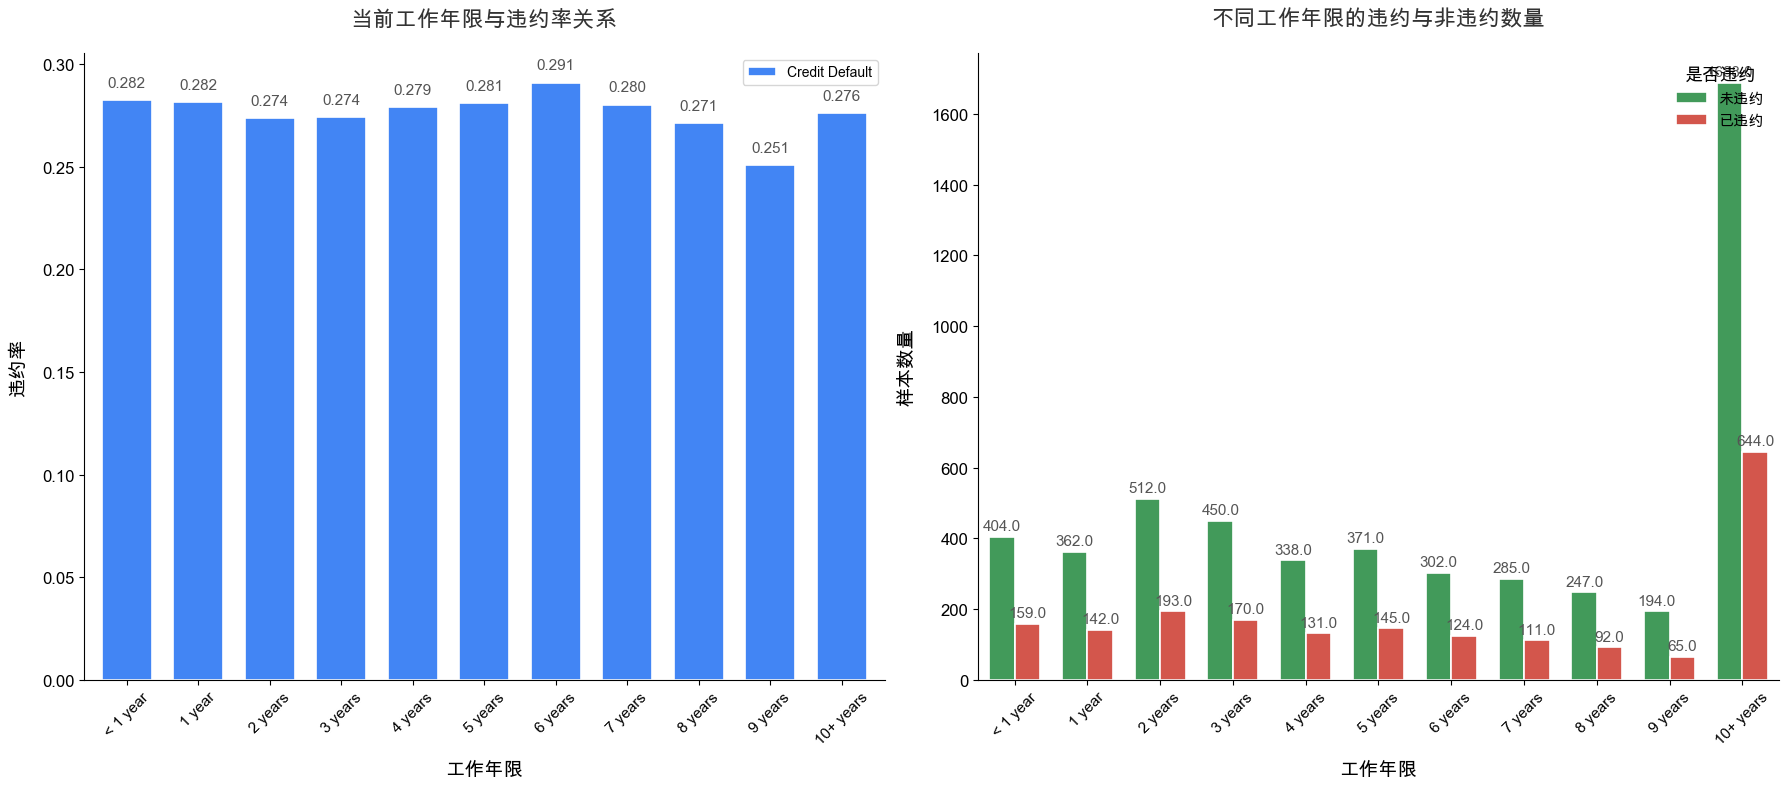

In [9]:
# 创建画布并调整布局
f, ax = plt.subplots(1, 2, figsize=(18, 8))
plt.subplots_adjust(wspace=0.3)  # 合理分配子图间距

# 定义专业配色（冷色调为主，适合时间维度数据）
mean_color = '#4285F4'  # 左侧均值图用蓝色
count_colors = ['#34A853', '#EA4335']  # 右侧计数图用绿/红（区分违约状态）

# 左侧：当前工作年限与违约率关系（均值图优化）
job_years_mean = train[['Years in current job', 'Credit Default']].groupby(['Years in current job']).mean()
# 按工作年限排序（避免无序显示）
sorted_years = ['< 1 year', '1 year', '2 years', '3 years', '4 years', '5 years', 
                '6 years', '7 years', '8 years', '9 years', '10+ years']
job_years_mean = job_years_mean.reindex(sorted_years)

job_years_mean.plot.bar(
    ax=ax[0],
    color=mean_color,
    width=0.7,
    edgecolor='white',  # 白色边框增强柱体立体感
    linewidth=1.2
)

# 左侧图标题与标签优化
ax[0].set_title('当前工作年限与违约率关系', fontsize=16, pad=20, fontweight='bold', color='#333333')
ax[0].set_xlabel('工作年限', fontsize=14, labelpad=10)
ax[0].set_ylabel('违约率', fontsize=14, labelpad=10)
ax[0].tick_params(axis='x', labelsize=11, rotation=45)  # 适度旋转避免标签重叠
ax[0].tick_params(axis='y', labelsize=12)

# 添加违约率数值标签（保留3位小数，更精确）
for p in ax[0].patches:
    ax[0].text(
        p.get_x() + p.get_width()/2, p.get_height() + 0.005,
        f'{p.get_height():.3f}',
        ha='center', va='bottom', fontsize=11, color='#555555'
    )

# 去除左侧图顶部和右侧边框
for spine in ax[0].spines.values():
    if spine.spine_type in ['top', 'right']:
        spine.set_visible(False)

# 右侧：不同工作年限的违约/非违约数量分布（计数图优化）
sns.countplot(
    x='Years in current job',
    hue='Credit Default',
    data=train,
    ax=ax[1],
    palette=count_colors,
    width=0.7,
    edgecolor='white',
    linewidth=1.2,
    order=sorted_years  # 按统一顺序排列
)

# 右侧图标题与标签优化
ax[1].set_title('不同工作年限的违约与非违约数量', fontsize=16, pad=20, fontweight='bold', color='#333333')
ax[1].set_xlabel('工作年限', fontsize=14, labelpad=10)
ax[1].set_ylabel('样本数量', fontsize=14, labelpad=10)
ax[1].tick_params(axis='x', labelsize=11, rotation=45)
ax[1].tick_params(axis='y', labelsize=12)

# 添加数量标签（仅显示有值的柱子）
for p in ax[1].patches:
    height = p.get_height()
    if height > 0:
        ax[1].text(
            p.get_x() + p.get_width()/2, height + 10,
            f'{height}',
            ha='center', va='bottom', fontsize=11, color='#555555'
        )

# 优化图例（明确含义，调整位置）
ax[1].legend(
    title='是否违约', 
    labels=['未违约', '已违约'],  # 中文标签更直观
    title_fontsize=13, 
    fontsize=11, 
    loc='upper right',
    frameon=False  # 去除图例边框
)

# 去除右侧图顶部和右侧边框
for spine in ax[1].spines.values():
    if spine.spine_type in ['top', 'right']:
        spine.set_visible(False)

# 整体布局调整，防止标签被截断
plt.tight_layout()
plt.show()

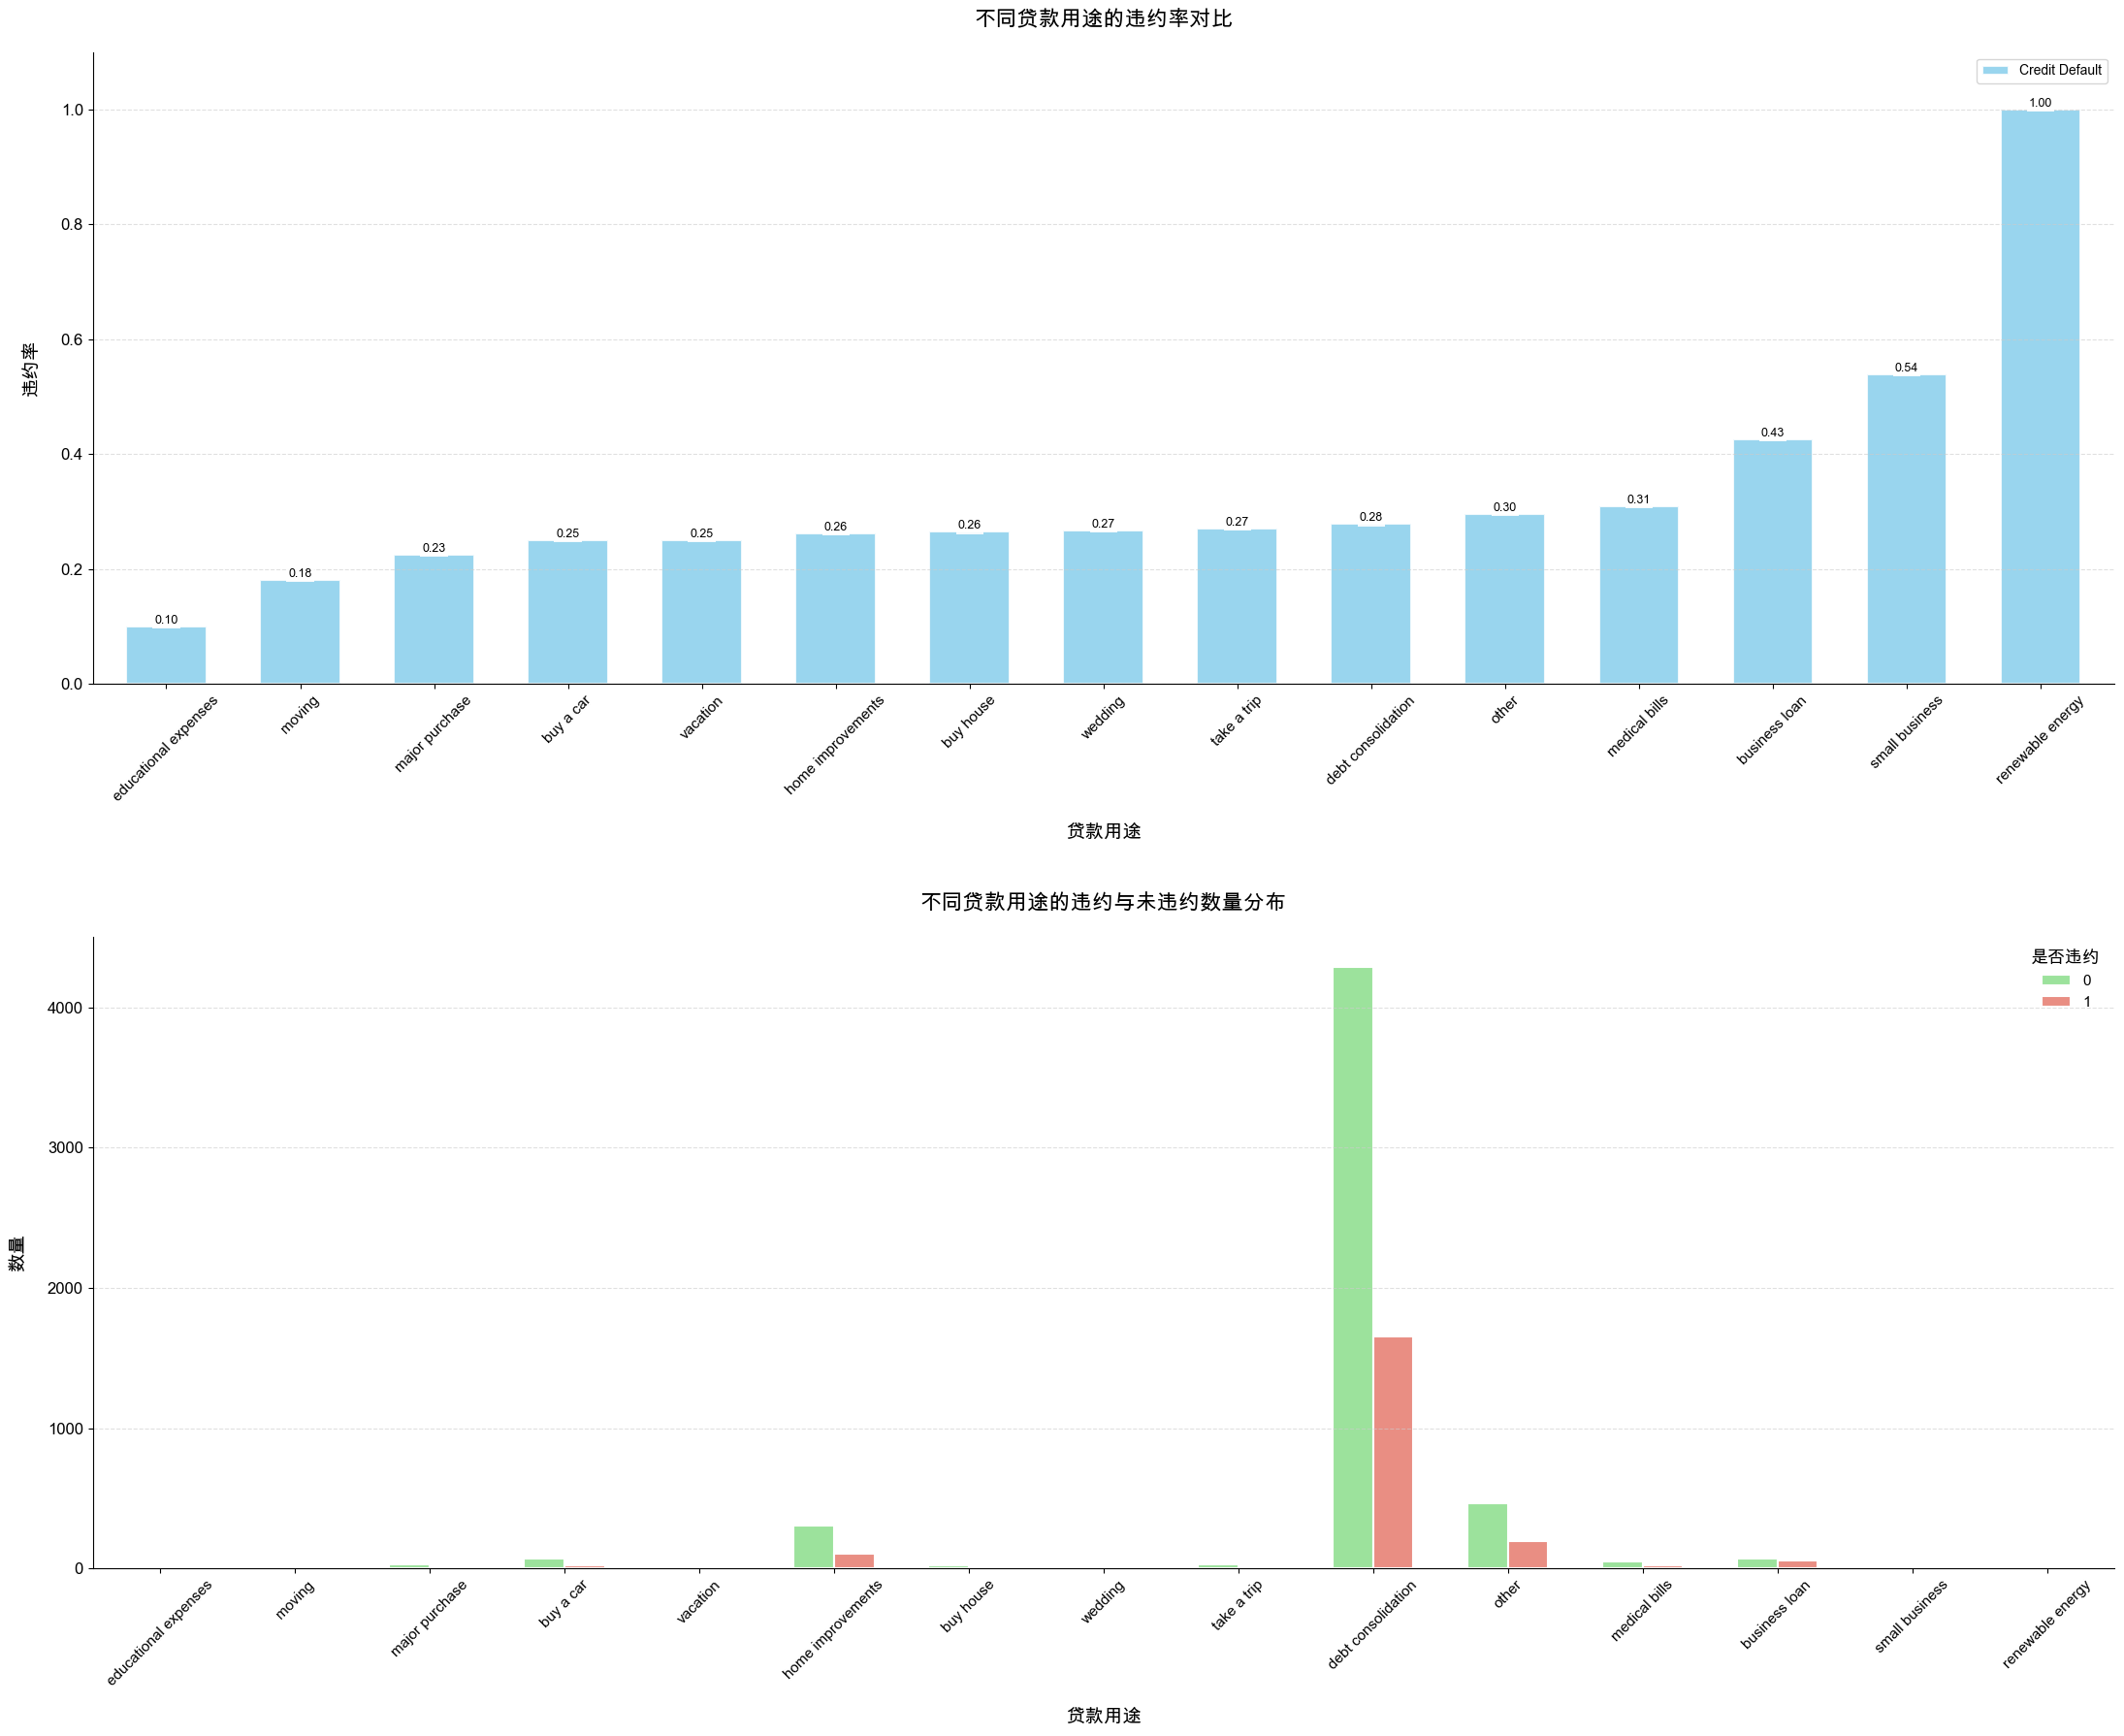

In [10]:
# 调整画布尺寸，给15个类别足够空间
f, ax = plt.subplots(2, 1, figsize=(22, 18))  # 适当加宽画布，避免标签重叠

# 数据预处理：按违约率排序
purpose_default = train[['Purpose', 'Credit Default']].groupby('Purpose').mean()
purpose_default = purpose_default.sort_values('Credit Default')

# 第一个子图：违约率柱状图（所有柱子显示占比）
purpose_default.plot.bar(ax=ax[0], width=0.6, edgecolor='white', linewidth=1.5, alpha=0.85, color='skyblue')

# 美化第一个子图
ax[0].set_title('不同贷款用途的违约率对比', fontsize=16, pad=20, fontweight='bold')
ax[0].set_xlabel('贷款用途', fontsize=14, labelpad=15)
ax[0].set_ylabel('违约率', fontsize=14, labelpad=15)
ax[0].grid(axis='y', linestyle='--', alpha=0.6, color='#cccccc')
ax[0].tick_params(axis='x', rotation=45, labelsize=11)  # 标签旋转45度，平衡可读性和空间
ax[0].tick_params(axis='y', labelsize=12)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].set_ylim(0, purpose_default['Credit Default'].max() * 1.1)  # 预留标签空间

# 为所有柱子添加占比标签（优化布局避免拥挤）
for p in ax[0].patches:
    height = p.get_height()
    ax[0].annotate(
        f'{height:.2f}',  # 保留两位小数
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='bottom',  # 水平居中，垂直靠下
        fontsize=9,  # 缩小字体避免拥挤
        rotation=0,  # 标签水平显示，更易读
        bbox=dict(facecolor='white', edgecolor='none', pad=1.5, alpha=0.9)  # 白色背景突出标签
    )

# 第二个子图：违约状态计数图（保持排序一致）
order = purpose_default.index
sns.countplot(
    x='Purpose', hue='Credit Default', data=train, ax=ax[1],
    order=order, width=0.6, edgecolor='white', linewidth=1.5,
    palette=['lightgreen', 'salmon']  # 区分违约状态的配色
)

# 美化第二个子图
ax[1].set_title('不同贷款用途的违约与未违约数量分布', fontsize=16, pad=20, fontweight='bold')
ax[1].set_xlabel('贷款用途', fontsize=14, labelpad=15)
ax[1].set_ylabel('数量', fontsize=14, labelpad=15)
ax[1].grid(axis='y', linestyle='--', alpha=0.6, color='#cccccc')
ax[1].tick_params(axis='x', rotation=45, labelsize=11)
ax[1].tick_params(axis='y', labelsize=12)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].legend(title='是否违约', title_fontsize=13, fontsize=11, loc='upper right', frameon=False)

# 调整整体布局
plt.tight_layout()
plt.subplots_adjust(hspace=0.4)  # 上下子图间距
plt.show()

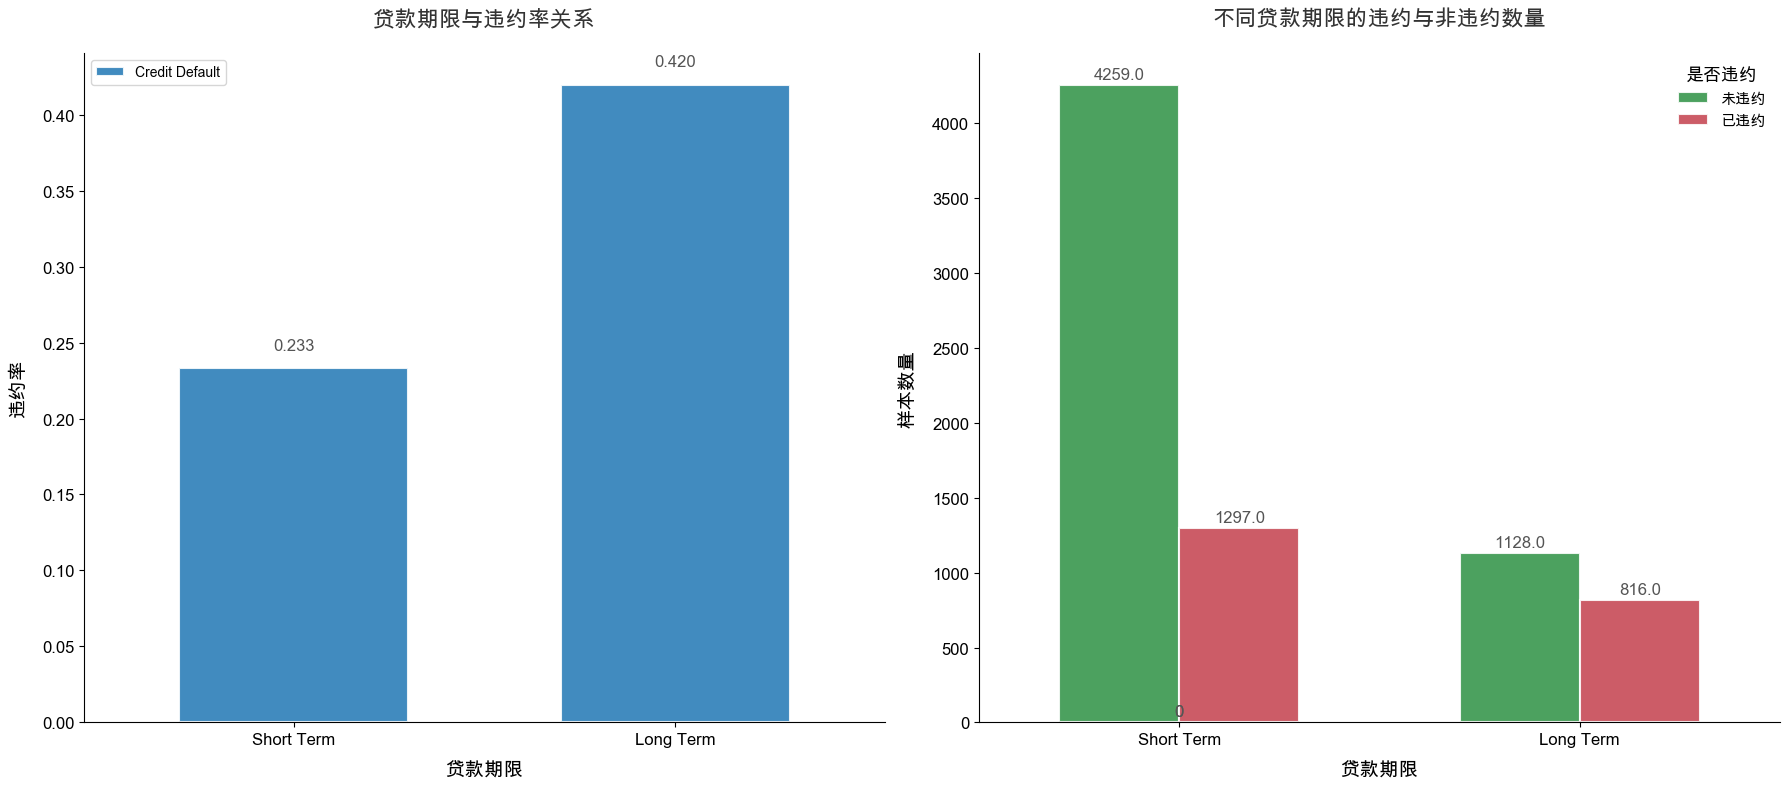

In [11]:
# 创建画布并调整布局（适当加宽间距）
f, ax = plt.subplots(1, 2, figsize=(18, 8))
plt.subplots_adjust(wspace=0.3)  # 增加子图间距，避免拥挤

# 定义专业配色（适合二/三类别对比，色调和谐）
mean_color = '#2C7FB8'  # 左侧均值图用深蓝色
count_colors = ['#28A745', '#DC3545']  # 右侧计数图用绿/红（区分违约状态）

# 左侧：贷款期限与违约率关系（均值图优化）
term_mean = train[['Term', 'Credit Default']].groupby(['Term']).mean()
# 按贷款期限合理排序（如短→长）
sorted_terms = ['Short Term', 'Long Term']  # 根据实际数据调整，确保逻辑顺序
term_mean = term_mean.reindex(sorted_terms)

term_mean.plot.bar(
    ax=ax[0],
    color=mean_color,
    width=0.6,  # 适中柱宽，避免过宽显得松散
    edgecolor='white',
    linewidth=1.5,
    alpha=0.9  # 轻微透明，增强层次感
)

# 左侧标题与标签优化
ax[0].set_title('贷款期限与违约率关系', fontsize=16, pad=20, fontweight='bold', color='#333333')
ax[0].set_xlabel('贷款期限', fontsize=14, labelpad=10)
ax[0].set_ylabel('违约率', fontsize=14, labelpad=10)
ax[0].tick_params(axis='x', labelsize=12, rotation=0)  # 期限类别少，无需旋转标签
ax[0].tick_params(axis='y', labelsize=12)

# 添加违约率数值标签（保留3位小数）
for p in ax[0].patches:
    ax[0].text(
        p.get_x() + p.get_width()/2, p.get_height() + 0.01,
        f'{p.get_height():.3f}',
        ha='center', va='bottom', fontsize=12, color='#555555'
    )

# 去除左侧图顶部和右侧边框
for spine in ax[0].spines.values():
    if spine.spine_type in ['top', 'right']:
        spine.set_visible(False)

# 右侧：不同贷款期限的违约/非违约数量分布（计数图优化）
sns.countplot(
    x='Term',
    hue='Credit Default',
    data=train,
    ax=ax[1],
    palette=count_colors,
    width=0.6,
    edgecolor='white',
    linewidth=1.5,
    alpha=0.9,
    order=sorted_terms  # 与左侧顺序一致，便于对比
)

# 右侧标题与标签优化
ax[1].set_title('不同贷款期限的违约与非违约数量', fontsize=16, pad=20, fontweight='bold', color='#333333')
ax[1].set_xlabel('贷款期限', fontsize=14, labelpad=10)
ax[1].set_ylabel('样本数量', fontsize=14, labelpad=10)
ax[1].tick_params(axis='x', labelsize=12, rotation=0)  # 不旋转标签，保持整洁
ax[1].tick_params(axis='y', labelsize=12)

# 添加数量标签
for p in ax[1].patches:
    height = p.get_height()
    ax[1].text(
        p.get_x() + p.get_width()/2, height + 20,  # 偏移量适配数量级
        f'{height}',
        ha='center', va='bottom', fontsize=12, color='#555555'
    )

# 优化图例（明确中文含义，调整位置）
ax[1].legend(
    title='是否违约',
    labels=['未违约', '已违约'],
    title_fontsize=13,
    fontsize=11,
    loc='upper right',
    frameon=False  # 去除边框，更简洁
)

# 去除右侧图顶部和右侧边框
for spine in ax[1].spines.values():
    if spine.spine_type in ['top', 'right']:
        spine.set_visible(False)

# 整体布局调整，确保标签完整显示
plt.tight_layout()
plt.show()

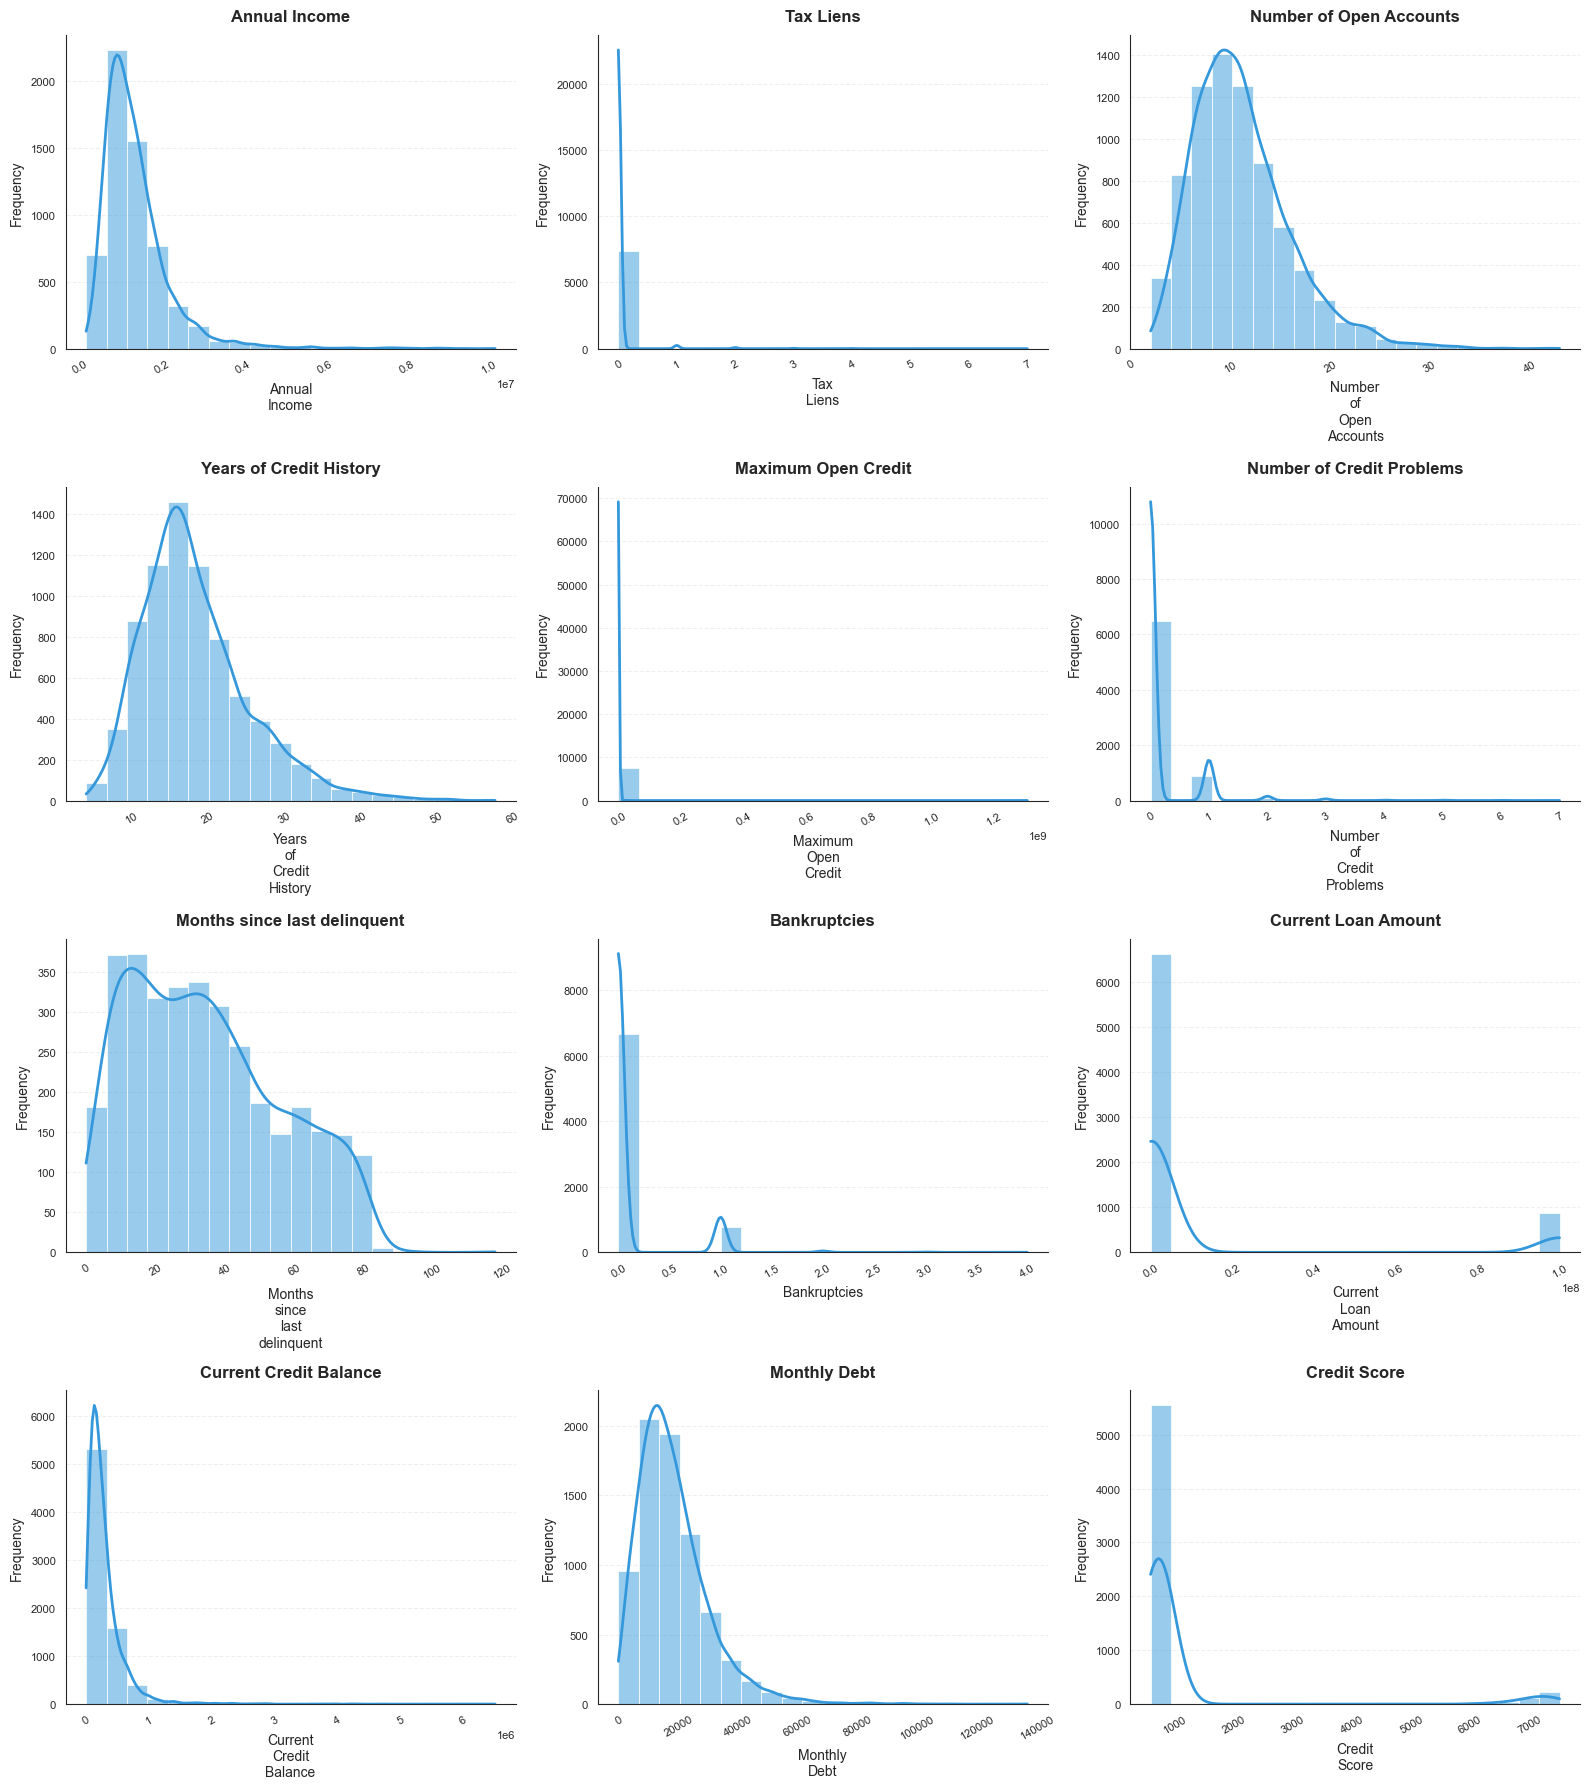

In [12]:
sns.set_style("white")
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8
NUM_FEATURE_NAMES = [
    'Annual Income', 'Tax Liens', 'Number of Open Accounts', 
    'Years of Credit History', 'Maximum Open Credit',
    'Number of Credit Problems', 'Months since last delinquent', 
    'Bankruptcies', 'Current Loan Amount', 'Current Credit Balance', 
    'Monthly Debt', 'Credit Score'
]

# 计算子图布局（4行3列）
n_rows = 4
n_cols = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 18))
axes = axes.flatten()

for i, feature in enumerate(NUM_FEATURE_NAMES):
    ax = axes[i]
    
    # 修正：将kde的颜色参数移至line_kws
    sns.histplot(
        data=train,  # 注意这里使用你的train数据
        x=feature, 
        bins=20, 
        kde=True,
        ax=ax,
        color='#3498db',  # 直方图颜色
        edgecolor='white',
        linewidth=0.5,
        kde_kws={},  # KDE本身不接受color参数
        line_kws={  # 核密度曲线的样式参数
            'color': '#e74c3c',  # 核密度曲线颜色
            'linewidth': 2
        }
    )
    
    # 设置标题和标签
    ax.set_title(f'{feature}', pad=10, fontweight='bold')
    ax.set_xlabel(feature.replace(' ', '\n'), labelpad=5)  # 长名称换行
    ax.set_ylabel('Frequency', labelpad=5)
    
    # 美化坐标轴
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', rotation=30)
    
    # 添加网格线
    ax.yaxis.grid(True, linestyle='--', alpha=0.3)
    ax.set_axisbelow(True)

# 调整布局
plt.tight_layout()
plt.show()

# <a id='toc5_'></a>[工具函数](#toc0_)

In [13]:
def f1_best_threshold(y_true, y_prob):
    """返回最大化 F1 的阈值与对应 F1"""
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    f1s = 2 * (precision * recall) / (precision + recall + 1e-8)
    best_idx = np.argmax(f1s)
    return thresholds[best_idx], f1s[best_idx]



# <a id='toc6_'></a>[数据预处理](#toc0_)


功能：处理数据中的缺失值和异常值，同时记录异常/缺失标记，为建模做准备

In [14]:
class DataPreprocessing:
    def __init__(self):
        # 存储数值型特征的中位数（用于填充缺失值）
        self.medians = None
        # 存储特征的众数（主要用于类别型特征的缺失值填充）
        self.modes = None
        # 信用分的合理最大值（根据业务知识设定，用于判断异常值）
        self.max_score = 850
        # 信贷相关特征的合理最大值（用于判断异常值）
        self.max_credit = 99999999.0

    def fit(self, X):
        """从训练数据中学习统计特征（中位数、众数）"""
        # 复制输入数据，避免修改原始数据
        X = X.copy()
        # 计算所有数值型特征的中位数（忽略非数值型特征）
        self.medians = X.median(numeric_only=True)
        # 计算所有特征的众数（取第一个众数，若存在多个众数）
        self.modes = X.mode().iloc[0]

    def transform(self, X):
        """对数据进行清洗转换：处理异常值、填充缺失值、添加标记列"""
        # 复制输入数据，避免修改原始数据
        X = X.copy()

        # --------------------------
        # 1. 处理 Credit Score（信用分）
        # --------------------------
        # 新增异常值标记列（初始值0表示正常）和缺失值标记列（初始值0表示无缺失）
        X['Credit Score Outlier'] = 0; X['Credit Score NaN'] = 0
        # 当信用分超过合理最大值时，标记为异常（1表示异常）
        X.loc[X['Credit Score'] > self.max_score, 'Credit Score Outlier'] = 1
        # 当信用分为缺失值时，标记为缺失（1表示缺失）
        X.loc[X['Credit Score'].isna(), 'Credit Score NaN'] = 1
        # 异常值修正：超过最大值的信用分除以10（假设是录入时多写一位，如8500→850）
        X.loc[X['Credit Score'] > self.max_score, 'Credit Score'] /= 10
        # 缺失值填充：用训练数据的信用分中位数填充
        X['Credit Score'].fillna(self.medians['Credit Score'], inplace=True)

        # --------------------------
        # 2. 处理 Current Loan Amount（当前贷款金额）
        # --------------------------
        # 新增异常值标记列（初始值0表示正常）
        X['Current Loan Amount Outlier'] = 0
        # 当贷款金额等于设定的极端值时，标记为异常
        X.loc[X['Current Loan Amount'] == self.max_credit, 'Current Loan Amount Outlier'] = 1
        # 异常值修正：用训练数据的贷款金额中位数替换极端值
        X.loc[X['Current Loan Amount'] == self.max_credit, 'Current Loan Amount'] = self.medians['Current Loan Amount']

        # --------------------------
        # 3. 处理 Maximum Open Credit（最大开放信贷）
        # --------------------------
        # 新增异常值标记列（初始值0表示正常）
        X['Maximum Open Credit Outlier'] = 0
        # 当最大开放信贷超过设定的最大值时，标记为异常
        X.loc[X['Maximum Open Credit'] > self.max_credit, 'Maximum Open Credit Outlier'] = 1
        # 异常值修正：超过最大值的部分截断为最大值
        X.loc[X['Maximum Open Credit'] > self.max_credit, 'Maximum Open Credit'] = self.max_credit

        # --------------------------
        # 4. 处理 Annual Income（年收入）
        # --------------------------
        # 新增缺失值标记列（初始值0表示无缺失）
        X['Annual Income NaN'] = 0
        # 当年收入为缺失值时，标记为缺失
        X.loc[X['Annual Income'].isna(), 'Annual Income NaN'] = 1
        # 缺失值填充：用训练数据的年收入中位数填充
        X['Annual Income'].fillna(self.medians['Annual Income'], inplace=True)

        # --------------------------
        # 5. 处理 Years in current job（当前工作年限）
        # --------------------------
        # 新增缺失值标记列（初始值0表示无缺失）
        X['Years in current job NaN'] = 0
        # 当工作年限为缺失值时，标记为缺失
        X.loc[X['Years in current job'].isna(), 'Years in current job NaN'] = 1
        # 缺失值填充：用训练数据的工作年限众数填充（工作年限更可能是类别型数据）
        X['Years in current job'].fillna(self.modes['Years in current job'], inplace=True)

        # --------------------------
        # 6. 处理 Bankruptcies（破产次数）
        # --------------------------
        # 新增缺失值标记列（初始值0表示无缺失）
        X['Bankruptcies NaN'] = 0
        # 当破产次数为缺失值时，标记为缺失
        X.loc[X['Bankruptcies'].isna(), 'Bankruptcies NaN'] = 1
        # 缺失值填充：用训练数据的破产次数中位数填充
        X['Bankruptcies'].fillna(self.medians['Bankruptcies'], inplace=True)

        # --------------------------
        # 7. 处理剩余未填充的缺失值
        # --------------------------
        # 对上述步骤未覆盖的其他缺失值，统一用对应特征的中位数填充
        X.fillna(self.medians, inplace=True)

        # 返回处理后的数据集
        return X

# <a id='toc7_'></a>[特征工程](#toc0_)

1. **类别特征编码处理**  
   对贷款期限（Term）二值化、工作年限（Years in current job）有序编码、住房所有权（Home Ownership）独热编码，同时对贷款用途（Purpose）等做频数编码，将非数值类别特征转化为模型可使用的格式。

2. **数值特征优化转换**  
   按标准区间对信用评分（Credit Score）分箱并填充缺失值，对年收入、贷款金额等数值特征做对数变换，缓解数据偏度，提升数值特征对模型的适配性。

3. **关键新特征构建**  
   计算债务比率、信贷利用率等财务比例特征，生成“贷款用途-期限”类别交互特征，挖掘数据中隐藏的指标关联与组合效应，丰富特征维度。

4. **数据安全与完整性保障**  
   复制原始数据避免修改，通过条件判断确保特征存在再处理，将计算中出现的无穷值替换为缺失值，保障特征工程过程中数据的安全性与有效性。

In [15]:
class FeatureGenerator:
    """特征生成器类，用于对输入数据进行特征工程处理，生成模型所需的特征"""
    
    def transform(self, X):
        """
        对输入数据进行特征转换处理
        
        参数:
            X: pandas.DataFrame，原始输入数据
            
        返回:
            pandas.DataFrame，处理后的特征数据
        """
        # 复制输入数据，避免修改原始数据
        X = X.copy()

        # 1. 对Term（贷款期限）特征进行二值化处理
        # 将"Long Term"及其小写形式映射为1，"Short Term"及其小写形式映射为0
        X['Long Term'] = X['Term'].map({'Long Term':1, 'Short Term':0, 'long term':1, 'short term':0})

        # 2. 对Years in current job（当前工作年限）进行有序编码
        # 根据工作年限对风险的影响程度分组映射：
        # <1年、1年、2年、3年 → 0
        # 4年、5年、6年 → 1
        # 7年、8年、9年 → 2
        # 10年以上 → 3
        order = {'< 1 year':0,'1 year':0,'2 years':0,'3 years':0,
                    '4 years':1,'5 years':1,'6 years':1,
                    '7 years':2,'8 years':2,'9 years':2,'10+ years':3}
        X['Years in current job'] = X['Years in current job'].map(order)

        # 3. 对Home Ownership（住房所有权）进行独热编码
        # 生成以"Home_"为前缀的哑变量，并与原数据拼接
        X = pd.concat([X, pd.get_dummies(X['Home Ownership'], prefix='Home')], axis=1)

        # 4. 对Credit Score（信用评分）进行分箱处理
        # 按照标准信用评分区间划分：300-579、580-669、670-739、740-799、800-850
        # 缺失值填充为-1，转换为整数类型
        X['Credit Score Cat'] = pd.cut(
            X['Credit Score'], 
            bins=[300,579,669,739,799,850], 
            labels=False
        ).fillna(-1).astype(int)

        # 5. 生成比例特征（反映不同财务指标间的相对关系）
        # 债务比率：年债务与年收入之比
        X['DebtRatio'] = X['Monthly Debt'] * 12 / X['Annual Income']
        # 信贷利用率：当前贷款金额与最大可用信贷之比
        X['CreditUtilization'] = X['Current Loan Amount'] / X['Maximum Open Credit']
        # 信用余额比率：当前信用余额与最大可用信贷之比
        X['CreditBalanceRatio'] = X['Current Credit Balance'] / X['Maximum Open Credit']
        # 贷款收入比：当前贷款金额与年收入之比（+1避免除零）
        X['LoanIncomeRatio'] = X['Current Loan Amount'] / (X['Annual Income'] + 1)
        # 账户人均收入：年收入与开户数量之比（+1避免除零）
        X['IncomePerAccount'] = X['Annual Income'] / (X['Number of Open Accounts'] + 1)
        # 开户密度：开户数量与信用历史年限之比（+1避免除零）
        X['OpenAccountDensity'] = X['Number of Open Accounts'] / (X['Years of Credit History'] + 1)
        # 问题密度：信用问题数量与信用历史年限之比（+1避免除零）
        X['ProblemDensity'] = X['Number of Credit Problems'] / (X['Years of Credit History'] + 1)

        # 6. 对类别特征进行频数编码（反映类别在整体中的占比）
        # 对Purpose（贷款用途）、Home Ownership（住房所有权）、Term（贷款期限）生成频率特征
        for c in ['Purpose', 'Home Ownership', 'Term']:
            if c in X.columns:  # 确保特征存在于数据中
                # 计算每个类别的出现频率
                freq = X[c].value_counts()
                # 映射频率值，生成新特征
                X[f'{c}_freq'] = X[c].map(freq / len(X))

        # 7. 生成类别交互特征（捕捉类别间的组合效应）
        # 组合贷款用途与贷款期限特征
        X['Purpose_Term'] = X['Purpose'].astype(str) + '_' + X['Term'].astype(str)

        # 8. 对数值特征进行对数变换（缓解数据偏度，使分布更接近正态）
        # 对收入、贷款金额等财务指标进行log(1+x)变换（避免零值问题）
        for col in ['Annual Income', 'Current Loan Amount', 'Maximum Open Credit',
                    'Current Credit Balance', 'Monthly Debt', 'Credit Score']:
            if col in X.columns:  # 确保特征存在于数据中
                # 替换空格为下划线作为新特征名，对非负值进行对数变换
                X[f'log_{col.replace(" ","_")}'] = np.log1p(X[col].clip(lower=0))

        # 处理可能出现的无穷值，替换为缺失值
        X.replace([np.inf, -np.inf], np.nan, inplace=True)
        
        # 返回处理后的特征数据
        return X

1. 从训练数据中分离目标变量（转为整数）和特征数据，复制测试数据。
2. 用训练特征拟合预处理模型，再分别对训练和测试特征做预处理。
3. 通过特征生成器对预处理后的训练、测试特征进行特征工程，确保处理一致性，为建模做准备。

In [16]:
# 定义目标变量列名（信用违约标识）
target_col = "Credit Default"

# 从训练数据中提取目标变量，并转换为整数类型（确保模型能正确处理标签）
y = train[target_col].astype(int)

# 从训练数据中删除目标变量列，得到纯特征数据（用于模型训练的输入特征）
train_X = train.drop(columns=[target_col])

# 复制测试数据（避免后续操作修改原始测试数据）
test_X  = test.copy()

# 初始化数据预处理类实例（假设该类包含缺失值处理、异常值处理等基础预处理逻辑）
preprocessor = DataPreprocessing()

# 用训练数据拟合预处理模型（学习训练数据中的统计特性，如缺失值填充策略等）
preprocessor.fit(train_X)

# 对训练特征数据应用预处理（使用拟合好的参数对训练数据进行转换）
train_proc = preprocessor.transform(train_X)

# 对测试特征数据应用同样的预处理（保证训练集和测试集处理方式一致）
test_proc  = preprocessor.transform(test_X)

# 初始化特征生成器实例（即前面定义的FeatureGenerator类，用于生成高级特征）
feat_gen = FeatureGenerator()

# 对预处理后的训练数据进行特征工程（生成衍生特征，如比例特征、交互特征等）
train_fe = feat_gen.transform(train_proc)

# 对预处理后的测试数据进行同样的特征工程（保持特征一致性）
test_fe  = feat_gen.transform(test_proc)



1. 精准划分特征类型
2. 为不同特征类型构建专属处理管道
3. 整合列转换器与应用完整处理流程

In [17]:
# 划分类别型特征列：筛选数据类型为object的列（通常为字符串类型的类别特征）
cat_cols = [c for c in train_fe.columns if train_fe[c].dtype == 'object' or train_fe[c].dtype == 'str']

# 划分数值型特征列：除类别特征外的其他列（通常为int/float类型的连续或离散数值特征）
num_cols = [c for c in train_fe.columns if c not in cat_cols]


# 构建数值型特征处理管道（使用Pipeline串联多个处理步骤）
numeric_pipe = Pipeline([
    # 缺失值处理：用该特征的中位数填充缺失值（对异常值不敏感，适合数值特征）
    # 这里作为"双重保障"，处理可能在之前预处理中未完全处理的剩余缺失值
    ('imputer', SimpleImputer(strategy='median'))  
])


# 构建类别型特征处理管道
categoric_pipe = Pipeline([
    # 缺失值处理：用该特征的众数（出现频率最高的值）填充缺失值（适合类别特征）
    ('imputer', SimpleImputer(strategy='most_frequent')),
    # 独热编码：将类别特征转换为哑变量（如"性别"→"性别_男"/"性别_女"）
    # handle_unknown='ignore'：测试集中出现训练集未见过的类别时，不报错且该类别对应哑变量均为0
    ('onehot', OneHotEncoder(handle_unknown='ignore'))     
])


# 构建完整的列转换器（将不同处理管道应用到对应的特征列）
preprocess = ColumnTransformer([
        # 对数值特征应用数值处理管道，指定处理的列名为num_cols
        ('num', numeric_pipe, num_cols),
        # 对类别特征应用类别处理管道，指定处理的列名为cat_cols
        ('cat', categoric_pipe, cat_cols)
    ], 
    remainder='drop'  # 对于未在num_cols和cat_cols中的列，直接丢弃（不纳入模型）
)


# 用训练集拟合完整的预处理流程（学习数值特征的中位数、类别特征的众数和编码规则等）
# 并对训练特征数据进行最终转换，得到可直接输入模型的特征矩阵
X_full = preprocess.fit_transform(train_fe)

# 用拟合好的预处理流程转换测试特征数据（保证与训练集处理逻辑完全一致）
X_test = preprocess.transform(test_fe)

# <a id='toc8_'></a>[贝叶斯优化参数空间](#toc0_)

In [18]:
class TunedMLP(MLPClassifier):
    def __init__(self, layer_idx=0, activation='relu', alpha=0.0001, 
                 learning_rate_init=0.001, max_iter=200, early_stopping=False, 
                 random_state=None):
        
        # 必须将参数绑定到 self 上，且名称与 __init__ 参数名完全一致
        self.layer_idx = layer_idx
        self.activation = activation
        self.alpha = alpha
        self.learning_rate_init = learning_rate_init
        self.max_iter = max_iter
        self.early_stopping = early_stopping
        self.random_state = random_state
        
        # 定义层结构映射
        self.layer_configs = [
            (50,),      # index 0
            (100,),     # index 1
            (50, 50)    # index 2
        ]

        super().__init__(
            hidden_layer_sizes=self.layer_configs[0], 
            activation=activation,
            alpha=alpha,
            learning_rate_init=learning_rate_init,
            max_iter=max_iter,
            early_stopping=early_stopping,
            random_state=random_state
        )

    def fit(self, X, y):
        # 关键步骤：每次 fit 前，根据当前的 layer_idx 更新 hidden_layer_sizes
        idx = int(self.layer_idx)
        # 边界保护
        if idx < 0 or idx >= len(self.layer_configs):
            idx = 0
        self.hidden_layer_sizes = self.layer_configs[idx]
        
        return super().fit(X, y)
    
def bayes_opt_serial(model, space, X, y, n_iter=12):
    opt = BayesSearchCV(
        model, space, n_iter=n_iter, cv=3, scoring='f1',
        random_state=42, n_jobs=1, verbose=0  # 改为单进程
    )
    opt.fit(X, y)
    return opt.best_estimator_, opt.best_params_

def bayes_opt(model, space, X, y, cv=3, n_iter=15, scoring='f1', rnd=42):
    """通用贝叶斯优化"""
    opt = BayesSearchCV(
        model, space, n_iter=n_iter, cv=cv, scoring=scoring,
        random_state=rnd, n_jobs=-1, verbose=0
    )
    opt.fit(X, y)
    return opt.best_estimator_, opt.best_params_

In [19]:
# 类别权重
class_weight = len(y) / (2 * np.bincount(y))

lgb_space = {
    'n_estimators': Integer(300, 1500),
    'learning_rate': Real(0.01, 0.1, prior='log-uniform'),
    'num_leaves': Integer(20, 100),
    'max_depth': Integer(3, 10),
    'min_child_samples': Integer(10, 100),
    'reg_alpha': Real(0.1, 1.0),
    'reg_lambda': Real(0.1, 1.0),
}

xgb_space = {
    'n_estimators': Integer(300, 1500),
    'learning_rate': Real(0.01, 0.1, prior='log-uniform'),
    'max_depth': Integer(3, 10),
    'min_child_weight': Integer(1, 10),
    'gamma': Real(0, 0.5),
    'subsample': Real(0.6, 1.0),
    'colsample_bytree': Real(0.6, 1.0),
    'reg_alpha': Real(0.1, 1.0),
    'reg_lambda': Real(0.1, 1.0),
}

cat_space = {
    'iterations': Integer(300, 1500),
    'learning_rate': Real(0.01, 0.1, prior='log-uniform'),
    'depth': Integer(3, 10),
    'l2_leaf_reg': Real(0.1, 10.0),
}

# 1. 逻辑回归 (Logistic Regression)
lr_space = {
    'C': Real(1e-3, 1e2, prior='log-uniform'), # 正则化强度
    'penalty': Categorical(['l2']),            # lbfgs solver 只支持 l2 或 None
    'solver': Categorical(['lbfgs', 'liblinear']) 
}

# 2. 支持向量机 (SVM)
svc_space = {
    'C': Real(1e-3, 1e2, prior='log-uniform'),
    'kernel': Categorical(['linear', 'rbf']),  # 常用核函数
    'gamma': Categorical(['scale', 'auto']),   # RBF核参数
}

# 3. 决策树 (Decision Tree)
dt_space = {
    'max_depth': Integer(3, 10),
    'min_samples_split': Integer(2, 20),
    'min_samples_leaf': Integer(1, 10),
    'criterion': Categorical(['gini', 'entropy'])
}

# 4. 随机森林 (Random Forest)
rf_space = {
    'n_estimators': Integer(100, 500),
    'max_depth': Integer(3, 10),
    'min_samples_split': Integer(2, 20),
    'max_features': Categorical(['sqrt', 'log2']),
    'bootstrap': Categorical([True, False])
}

# 5. 梯度提升树 (GBDT - Sklearn原生)
gbdt_space = {
    'n_estimators': Integer(100, 500),
    'learning_rate': Real(0.01, 0.2, prior='log-uniform'),
    'max_depth': Integer(3, 10),
    'subsample': Real(0.6, 1.0),
    'min_samples_split': Integer(2, 20)
}

# 6. 朴素贝叶斯 (Gaussian Naive Bayes)
# 朴素贝叶斯参数很少，主要是方差平滑
nb_space = {
    'var_smoothing': Real(1e-9, 1e-5, prior='log-uniform')
}

# 7. 多层感知机 (MLP / Neural Network)
mlp_space = {
    'layer_idx': Categorical([0, 1, 2]), # 对应上面的 configs
    'activation': Categorical(['tanh', 'relu']),
    'alpha': Real(1e-5, 1e-2, prior='log-uniform'),
    'learning_rate_init': Real(1e-4, 0.01, prior='log-uniform')
}

# ------------------------------------------------------------------
# 小样本快速优化（用 3 折 & 800 样本）
# ------------------------------------------------------------------
sample_idx, _ = train_test_split(
    np.arange(len(X_full)), stratify=y, train_size=800, random_state=42)
X_sample, y_sample = X_full[sample_idx], y.iloc[sample_idx]

In [20]:
# ================= 基础模型 (Sklearn) =================
print('【逻辑回归 (LR) 贝叶斯优化】')
lr_model, lr_best = bayes_opt(
    LogisticRegression(max_iter=2000, random_state=42, n_jobs=-1),
    lr_space, X_sample, y_sample, n_iter=12)

print('【支持向量机 (SVM) 贝叶斯优化】')
# SVM 训练较慢，probability=True 会更慢，但在小样本(800)下可接受
svm_model, svm_best = bayes_opt(
    SVC(probability=False, class_weight='balanced', random_state=42),
    svc_space, X_sample, y_sample, n_iter=1)

print('【决策树 (DT) 贝叶斯优化】')
dt_model, dt_best = bayes_opt(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    dt_space, X_sample, y_sample, n_iter=12)

print('【随机森林 (RF) 贝叶斯优化】')
rf_model, rf_best = bayes_opt(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    rf_space, X_sample, y_sample, n_iter=12)

print('【GBDT (Sklearn) 贝叶斯优化】')
# Sklearn GBDT 原生不支持 class_weight 参数，通常需手动处理样本权重或忽略
gbdt_model, gbdt_best = bayes_opt(
    GradientBoostingClassifier(random_state=42),
    gbdt_space, X_sample, y_sample, n_iter=12)

print('【朴素贝叶斯 (NB) 贝叶斯优化】')
nb_model, nb_best = bayes_opt(
    GaussianNB(),
    nb_space, X_sample, y_sample, n_iter=12)

print('【MLP (神经网络) 贝叶斯优化】')
mlp_model, mlp_best = bayes_opt_serial(
    TunedMLP(max_iter=1000, early_stopping=True, random_state=42),
    mlp_space, X_sample, y_sample, n_iter=12
)

mlp_best = dict(mlp_best)
best_idx = int(mlp_best.pop('layer_idx')) # 移除 layer_idx
mlp_best['hidden_layer_sizes'] = [(50,), (100,), (50, 50)][best_idx] # 加回 hidden_layer_sizes

# ================= 提升树模型 (Boosting) =================
print('【LightGBM 贝叶斯优化】')
lgb_model, lgb_best = bayes_opt(
    lgb.LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1),
    lgb_space, X_sample, y_sample, n_iter=12)

print('【XGBoost 贝叶斯优化】')
# 确保 scale_pos_weight 已计算 (使用你之前代码中的 class_weight 变量)
xgb_scale_weight = class_weight[1] / class_weight[0] if 'class_weight' in locals() else 1.0
xgb_model, xgb_best = bayes_opt(
    xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss',
                      scale_pos_weight=xgb_scale_weight,
                      tree_method='hist', random_state=42, n_jobs=-1),
    xgb_space, X_sample, y_sample, n_iter=12)

print('【CatBoost 贝叶斯优化】')
cat_model, cat_best = bayes_opt(
    cb.CatBoostClassifier(loss_function='Logloss', eval_metric='F1',
                          auto_class_weights='Balanced', # 建议显式开启自动平衡
                          thread_count=-1, random_state=42, verbose=False),
    cat_space, X_sample, y_sample, n_iter=12)

【逻辑回归 (LR) 贝叶斯优化】
【支持向量机 (SVM) 贝叶斯优化】
【决策树 (DT) 贝叶斯优化】
【随机森林 (RF) 贝叶斯优化】
【GBDT (Sklearn) 贝叶斯优化】
【朴素贝叶斯 (NB) 贝叶斯优化】
【MLP (神经网络) 贝叶斯优化】
【LightGBM 贝叶斯优化】
【XGBoost 贝叶斯优化】
【CatBoost 贝叶斯优化】


# <a id='toc9_'></a>[合成数据生成](#toc0_)
功能：通过KNN插值法为少数类生成合成样本，缓解数据不平衡问题

In [21]:
def augment_minority_knn(X, y, n_samples=1000, k=5):
    """
    仅对少数类做KNN插值生成合成样本
    
    参数:
        X: 特征数据，二维数组格式 (样本数, 特征数)
        y: 标签数据，一维数组格式 (样本数,)
        n_samples: 要生成的合成样本数量，默认1000
        k: KNN算法中考虑的近邻数量，默认5
        
    返回:
        X_syn: 原始特征数据 + 合成特征数据的组合
        y_syn: 原始标签数据 + 合成标签数据的组合
    """
    # 确定少数类标签：比较两类样本数量，数量少的为少数类
    # 假设标签只有0和1两种取值
    minority_label = 1 if np.sum(y == 1) < np.sum(y == 0) else 0
    
    # 提取少数类的特征数据
    X_min = X[y == minority_label]
    
    # 如果少数类样本数小于2，无法生成合成样本，直接返回原始数据
    if len(X_min) < 2:
        return X, y

    # 确定实际使用的近邻数：不超过k，且不超过少数类样本数-1（排除自身）
    n_neighbors = min(k, len(X_min) - 1)
    
    # 构建KNN模型，拟合少数类数据
    knn = NearestNeighbors(n_neighbors=n_neighbors).fit(X_min)
    
    # 用于存储生成的合成样本
    synthetic = []
    
    # 生成指定数量的合成样本
    for _ in range(n_samples):
        # 随机选择一个少数类样本作为基准样本
        idx = np.random.randint(0, len(X_min))
        
        # 找到该样本的k个近邻的索引
        # kneighbors返回距离和索引，这里只需要索引
        neigh_idx = knn.kneighbors([X_min[idx]], return_distance=False)[0]
        
        # 从近邻索引中删除基准样本自身（第一个元素是自身）
        neigh_idx = np.delete(neigh_idx, 0)
        
        # 如果没有其他近邻（理论上不会发生，因为前面已保证len(X_min)>=2）
        if len(neigh_idx) == 0:
            continue
        
        # 从近邻中随机选择一个样本
        neighbor = X_min[np.random.choice(neigh_idx)]
        
        # 生成0-1之间的随机权重
        alpha = np.random.rand()
        
        # 通过线性插值生成合成样本：基准样本和近邻样本的加权平均
        synthetic.append(alpha * X_min[idx] + (1 - alpha) * neighbor)
    
    # 如果成功生成了合成样本
    if synthetic:
        # 将原始特征与合成特征组合
        X_syn = np.vstack([X, np.array(synthetic)])
        # 将原始标签与合成样本标签（少数类标签）组合
        y_syn = np.hstack([y, [minority_label] * len(synthetic)])
        return X_syn, y_syn
    
    # 如果没有生成合成样本，返回原始数据
    return X, y

# ------------------------------------------------------------------
# 数据采样策略
# 功能：提供多种数据采样策略接口，用于处理类别不平衡问题
# ------------------------------------------------------------------
def apply_sampling(X, y, strategy='smote'):
    """
    应用不同的数据采样策略处理类别不平衡问题
    
    参数:
        X: 特征数据，二维数组格式 (样本数, 特征数)
        y: 标签数据，一维数组格式 (样本数,)
        strategy: 采样策略，可选值包括：
                  'none': 不进行采样
                  'smote': 使用SMOTE算法过采样少数类
                  'undersample': 随机下采样多数类
                  'combined': 结合SMOTE和ENN的采样方法
                  'knn': 使用自定义的KNN插值法生成少数类样本
        
    返回:
        采样后的特征数据和标签数据
    """
    if strategy == 'none':
        # 不进行采样，直接返回原始数据
        return X, y
    
    elif strategy == 'smote':
        # 使用SMOTE算法过采样少数类
        # 注意：确保近邻数不超过少数类样本数-1
        smote = SMOTE(random_state=42, k_neighbors=min(5, np.sum(y == 1) - 1))
        return smote.fit_resample(X, y)
    
    elif strategy == 'undersample':
        # 使用随机下采样多数类
        rus = RandomUnderSampler(random_state=42)
        return rus.fit_resample(X, y)
    
    elif strategy == 'combined':
        # 使用SMOTEENN：先过采样少数类，再用ENN（编辑最近邻）方法清理样本
        sme = SMOTEENN(random_state=42)
        return sme.fit_resample(X, y)
    
    elif strategy == 'knn':
        # 使用自定义的KNN插值法生成少数类样本
        return augment_minority_knn(X, y, n_samples=1000)
    
    else:
        # 未知策略时抛出异常
        raise ValueError('Unknown strategy')

# 设置采样策略，可选值：none / smote / undersample / combined / knn
SAMPLING_STRATEGY = 'smote'
# 打印当前使用的采样策略
print(f'>>> 数据采样策略：{SAMPLING_STRATEGY}')

>>> 数据采样策略：smote


# <a id='toc10_'></a>[5 折交叉验证训练](#toc0_)

In [22]:
# ==========================================
# 1. 初始化所有模型的 OOF 和 Prediction 数组
# ==========================================
# 1.1 基础模型 (Sklearn)
oof_lr, pred_lr = np.zeros(len(X_full)), np.zeros(len(X_test))
oof_svm, pred_svm = np.zeros(len(X_full)), np.zeros(len(X_test))
oof_dt, pred_dt = np.zeros(len(X_full)), np.zeros(len(X_test))
oof_rf, pred_rf = np.zeros(len(X_full)), np.zeros(len(X_test))
oof_gbdt, pred_gbdt = np.zeros(len(X_full)), np.zeros(len(X_test))
oof_nb, pred_nb = np.zeros(len(X_full)), np.zeros(len(X_test))
oof_mlp, pred_mlp = np.zeros(len(X_full)), np.zeros(len(X_test))

# 1.2 提升树模型 (Boosting)
oof_lgb, pred_lgb = np.zeros(len(X_full)), np.zeros(len(X_test))
oof_xgb, pred_xgb = np.zeros(len(X_full)), np.zeros(len(X_test))
oof_cat, pred_cat = np.zeros(len(X_full)), np.zeros(len(X_test))

# ==========================================
# 2. 交叉验证循环
# ==========================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (tr, va) in enumerate(skf.split(X_full, y), 1):
    print(f'=== Fold {fold} / 5 ===')
    X_tr, X_va = X_full[tr], X_full[va]
    y_tr, y_va = y.iloc[tr], y.iloc[va]

    # --- 数据增强/采样 (仅对训练集) ---
    # 假设 apply_sampling 函数已定义，且能处理 class imbalance
    X_tr_res, y_tr_res = apply_sampling(X_tr, y_tr, strategy=SAMPLING_STRATEGY)

    # ------------------------------------------------------
    # A组：Sklearn 类模型 (标准 .fit 接口)
    # ------------------------------------------------------
    # 1. Logistic Regression
    m_lr = LogisticRegression(**lr_best, class_weight='balanced', max_iter=2000, random_state=42, n_jobs=-1)
    m_lr.fit(X_tr_res, y_tr_res)
    oof_lr[va] = m_lr.predict_proba(X_va)[:, 1]
    pred_lr += m_lr.predict_proba(X_test)[:, 1] / skf.n_splits

    # 2. SVM (注意: probability=True 必须开启，速度较慢)
    m_svm = SVC(**svm_best, probability=True, class_weight='balanced', random_state=42)
    m_svm.fit(X_tr_res, y_tr_res)
    oof_svm[va] = m_svm.predict_proba(X_va)[:, 1]
    pred_svm += m_svm.predict_proba(X_test)[:, 1] / skf.n_splits

    # 3. Decision Tree
    m_dt = DecisionTreeClassifier(**dt_best, class_weight='balanced', random_state=42)
    m_dt.fit(X_tr_res, y_tr_res)
    oof_dt[va] = m_dt.predict_proba(X_va)[:, 1]
    pred_dt += m_dt.predict_proba(X_test)[:, 1] / skf.n_splits

    # 4. Random Forest
    m_rf = RandomForestClassifier(**rf_best, class_weight='balanced', n_jobs=-1, random_state=42)
    m_rf.fit(X_tr_res, y_tr_res)
    oof_rf[va] = m_rf.predict_proba(X_va)[:, 1]
    pred_rf += m_rf.predict_proba(X_test)[:, 1] / skf.n_splits

    # 5. GBDT (Sklearn原生) - 不支持 class_weight
    m_gbdt = GradientBoostingClassifier(**gbdt_best, random_state=42)
    m_gbdt.fit(X_tr_res, y_tr_res)
    oof_gbdt[va] = m_gbdt.predict_proba(X_va)[:, 1]
    pred_gbdt += m_gbdt.predict_proba(X_test)[:, 1] / skf.n_splits

    # 6. Naive Bayes - 不支持 class_weight
    m_nb = GaussianNB(**nb_best)
    m_nb.fit(X_tr_res, y_tr_res)
    oof_nb[va] = m_nb.predict_proba(X_va)[:, 1]
    pred_nb += m_nb.predict_proba(X_test)[:, 1] / skf.n_splits

    # 7. MLP - 不直接支持 class_weight
    m_mlp = MLPClassifier(**mlp_best, max_iter=1000, random_state=42)
    m_mlp.fit(X_tr_res, y_tr_res)
    oof_mlp[va] = m_mlp.predict_proba(X_va)[:, 1]
    pred_mlp += m_mlp.predict_proba(X_test)[:, 1] / skf.n_splits

    # ------------------------------------------------------
    # B组：Boosting 类模型 (支持 eval_set 早停)
    # ------------------------------------------------------
    # 8. LightGBM
    m_lgb = lgb.LGBMClassifier(**lgb_best, class_weight='balanced', n_jobs=-1, verbose=-1)
    m_lgb.fit(X_tr_res, y_tr_res, eval_set=[(X_va, y_va)]) # callbacks=[lgb.early_stopping(50)] 可选
    oof_lgb[va] = m_lgb.predict_proba(X_va)[:, 1]
    pred_lgb += m_lgb.predict_proba(X_test)[:, 1] / skf.n_splits

    # 9. XGBoost
    # 计算 scale_pos_weight
    neg, pos = np.bincount(y_tr_res)
    spw = neg / pos
    m_xgb = xgb.XGBClassifier(**xgb_best, tree_method='hist', n_jobs=-1,
                              scale_pos_weight=spw, early_stopping_rounds=50)
    m_xgb.fit(X_tr_res, y_tr_res, eval_set=[(X_va, y_va)], verbose=0)
    oof_xgb[va] = m_xgb.predict_proba(X_va)[:, 1]
    pred_xgb += m_xgb.predict_proba(X_test)[:, 1] / skf.n_splits

    # 10. CatBoost
    m_cat = cb.CatBoostClassifier(**cat_best, thread_count=-1, verbose=False,
                                  auto_class_weights='Balanced', early_stopping_rounds=50)
    m_cat.fit(X_tr_res, y_tr_res, eval_set=(X_va, y_va))
    oof_cat[va] = m_cat.predict_proba(X_va)[:, 1]
    pred_cat += m_cat.predict_proba(X_test)[:, 1] / skf.n_splits

    # ------------------------------------------------------
    # C组：Fold 评估 (计算最佳 F1)
    # ------------------------------------------------------
    # 辅助函数: 计算单模型在当前 Fold 的最佳 F1
    def get_best_f1(y_true, y_prob):
        t, f = f1_best_threshold(y_true, y_prob)
        return f

    print(f"   [Sklearn] LR:{get_best_f1(y_va, oof_lr[va]):.3f} | SVM:{get_best_f1(y_va, oof_svm[va]):.3f} | DT:{get_best_f1(y_va, oof_dt[va]):.3f} | RF:{get_best_f1(y_va, oof_rf[va]):.3f}")
    print(f"   [Others]  GBDT:{get_best_f1(y_va, oof_gbdt[va]):.3f} | NB:{get_best_f1(y_va, oof_nb[va]):.3f} | MLP:{get_best_f1(y_va, oof_mlp[va]):.3f}")
    print(f"   [Boosting] LGB:{get_best_f1(y_va, oof_lgb[va]):.3f} | XGB:{get_best_f1(y_va, oof_xgb[va]):.3f} | CAT:{get_best_f1(y_va, oof_cat[va]):.3f}")
    print("-" * 50)

=== Fold 1 / 5 ===
   [Sklearn] LR:0.513 | SVM:0.439 | DT:0.526 | RF:0.548
   [Others]  GBDT:0.552 | NB:0.454 | MLP:0.452
   [Boosting] LGB:0.555 | XGB:0.554 | CAT:0.562
--------------------------------------------------
=== Fold 2 / 5 ===
   [Sklearn] LR:0.475 | SVM:0.439 | DT:0.526 | RF:0.553
   [Others]  GBDT:0.528 | NB:0.450 | MLP:0.451
   [Boosting] LGB:0.551 | XGB:0.543 | CAT:0.542
--------------------------------------------------
=== Fold 3 / 5 ===
   [Sklearn] LR:0.482 | SVM:0.440 | DT:0.521 | RF:0.563
   [Others]  GBDT:0.530 | NB:0.449 | MLP:0.440
   [Boosting] LGB:0.542 | XGB:0.542 | CAT:0.556
--------------------------------------------------
=== Fold 4 / 5 ===
   [Sklearn] LR:0.491 | SVM:0.440 | DT:0.532 | RF:0.551
   [Others]  GBDT:0.533 | NB:0.456 | MLP:0.447
   [Boosting] LGB:0.545 | XGB:0.549 | CAT:0.561
--------------------------------------------------
=== Fold 5 / 5 ===
   [Sklearn] LR:0.509 | SVM:0.440 | DT:0.525 | RF:0.555
   [Others]  GBDT:0.545 | NB:0.463 | MLP:

# <a id='toc11_'></a>[模型融合](#toc0_)

## <a id='toc11_1_'></a>[加权融合（权重按 OOF F1 的幂次）](#toc0_)

In [23]:
# 1. 整理所有模型的 OOF 和 预测值
# 格式: (模型名称, OOF数组, 预测数组)
model_list = [
    ('LR',   oof_lr,   pred_lr),
    ('SVM',  oof_svm,  pred_svm),
    ('DT',   oof_dt,   pred_dt),
    ('RF',   oof_rf,   pred_rf),
    ('GBDT', oof_gbdt, pred_gbdt),
    ('NB',   oof_nb,   pred_nb),
    ('MLP',  oof_mlp,  pred_mlp),
    ('LGB',  oof_lgb,  pred_lgb),
    ('XGB',  oof_xgb,  pred_xgb),
    ('CAT',  oof_cat,  pred_cat)
]

# 2. 计算每个单模型的最佳 F1 分数
f1_scores = []
print("=== 单模型 F1 表现 ===")
for name, oof, _ in model_list:
    # f1_best_threshold 返回 (threshold, f1_score)
    _, score = f1_best_threshold(y, oof)
    f1_scores.append(score)
    print(f"{name:4s}: {score:.4f}")

# 3. 计算权重 (基于 F1 分数的幂次)
power = 3  # 幂次越高，越倾向于表现最好的模型；幂次为0则为平均融合
weights = np.array(f1_scores) ** power
weights /= weights.sum()  # 归一化使总和为 1

print(f"\n=== 融合权重分配 (Power={power}) ===")
for i, (name, _, _) in enumerate(model_list):
    print(f"{name:4s}: {weights[i]:.4f}")

# 4. 执行加权融合
oof_blend = np.zeros(len(y))
pred_blend = np.zeros(len(pred_lgb))

for i, (_, oof, pred) in enumerate(model_list):
    oof_blend  += weights[i] * oof
    pred_blend += weights[i] * pred

# 5. 计算融合后的最终效果
best_thr, best_f1 = f1_best_threshold(y, oof_blend)
print(f'\n>>> 10模型加权融合 OOF F1 = {best_f1:.4f} @ threshold = {best_thr:.4f}')

=== 单模型 F1 表现 ===
LR  : 0.4875
SVM : 0.4396
DT  : 0.5205
RF  : 0.5473
GBDT: 0.5323
NB  : 0.4489
MLP : 0.4483
LGB : 0.5404
XGB : 0.5391
CAT : 0.5495

=== 融合权重分配 (Power=3) ===
LR  : 0.0879
SVM : 0.0645
DT  : 0.1070
RF  : 0.1244
GBDT: 0.1145
NB  : 0.0686
MLP : 0.0684
LGB : 0.1197
XGB : 0.1189
CAT : 0.1260

>>> 10模型加权融合 OOF F1 = 0.5464 @ threshold = 0.3933


## <a id='toc11_2_'></a>[Stacking（Logistic/RandomForest 选最佳）](#toc0_)

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
# ==========================================
# 1. 构建 Stacking 特征矩阵 (10维特征)
# ==========================================
# 将所有基础模型的 OOF 预测结果堆叠，作为元模型的训练集
stack_X = np.vstack([
    oof_lr, oof_svm, oof_dt, oof_rf, oof_gbdt, oof_nb, oof_mlp,  # 7个 Sklearn 模型
    oof_lgb, oof_xgb, oof_cat                                    # 3个 Boosting 模型
]).T

# 将所有基础模型的测试集预测结果堆叠，作为元模型的测试集
stack_test = np.vstack([
    pred_lr, pred_svm, pred_dt, pred_rf, pred_gbdt, pred_nb, pred_mlp,
    pred_lgb, pred_xgb, pred_cat
]).T

print(f"Stacking Train Shape: {stack_X.shape}") # 应该是 (样本数, 10)
print(f"Stacking Test Shape:  {stack_test.shape}")

# ==========================================
# 2. 定义并训练元模型 (Meta-Learners)
# ==========================================
# 这里通常选用简单的模型，避免在第二层过拟合
stack_models = {
    # 逻辑回归：最常用的 Stacking 元模型，类似于给每个基模型分配权重
    'LR': LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    
    # 随机森林：可以捕捉基模型之间的非线性关系
    'RF': RandomForestClassifier(n_estimators=200, max_depth=4, class_weight='balanced',
                                 random_state=42, n_jobs=-1)
}

stack_res = {}
best_score = -1
best_stack_name = None

print("\n=== 第二层 Stacking 模型训练 ===")
for name, mdl in stack_models.items():
    # 训练元模型
    mdl.fit(stack_X, y)
    
    # 预测概率
    prob_train = mdl.predict_proba(stack_X)[:, 1]
    
    # 使用你之前定义的辅助函数寻找最佳阈值（比固定 0.5 更稳健）
    # 这里的 score 是在 OOF 上再次训练得到的 Training Score，
    # 严格来说最好是有双层 CV，但简单 Stacking 中这样做是允许的。
    thr, f1 = f1_best_threshold(y, prob_train)
    
    stack_res[name] = {'model': mdl, 'f1': f1, 'threshold': thr}
    print(f'  [{name}] Stacking Training F1 = {f1:.4f} @ thr={thr:.4f}')
    
    if f1 > best_score:
        best_score = f1
        best_stack_name = name

# ==========================================
# 3. 输出最终结果
# ==========================================
print(f'\n>>> 最佳 Stacking 元模型：{best_stack_name}')

# 使用最佳模型对测试集进行预测
best_model = stack_res[best_stack_name]['model']
best_thr = stack_res[best_stack_name]['threshold']

# 生成最终提交的概率值
final_prob_test = best_model.predict_proba(stack_test)[:, 1]

# 如果需要生成最终的二分类标签 (0/1)
# final_pred_test = (final_prob_test >= best_thr).astype(int)

Stacking Train Shape: (7500, 10)
Stacking Test Shape:  (2500, 10)

=== 第二层 Stacking 模型训练 ===
  [LR] Stacking Training F1 = 0.5518 @ thr=0.4624
  [RF] Stacking Training F1 = 0.5630 @ thr=0.4793

>>> 最佳 Stacking 元模型：RF


# <a id='toc12_'></a>[提交文件](#toc0_)

In [25]:
sub = sample_sub.copy()
sub[target_col] = (pred_blend >= best_thr).astype(int)   # 也可换成 best_stack_pred
sub.to_csv(SUBMISSION_OUT, index=False)
print(f'>>> 提交文件已保存：{SUBMISSION_OUT}')

>>> 提交文件已保存：submission.csv


# <a id='toc13_'></a>[结果可视化](#toc0_)

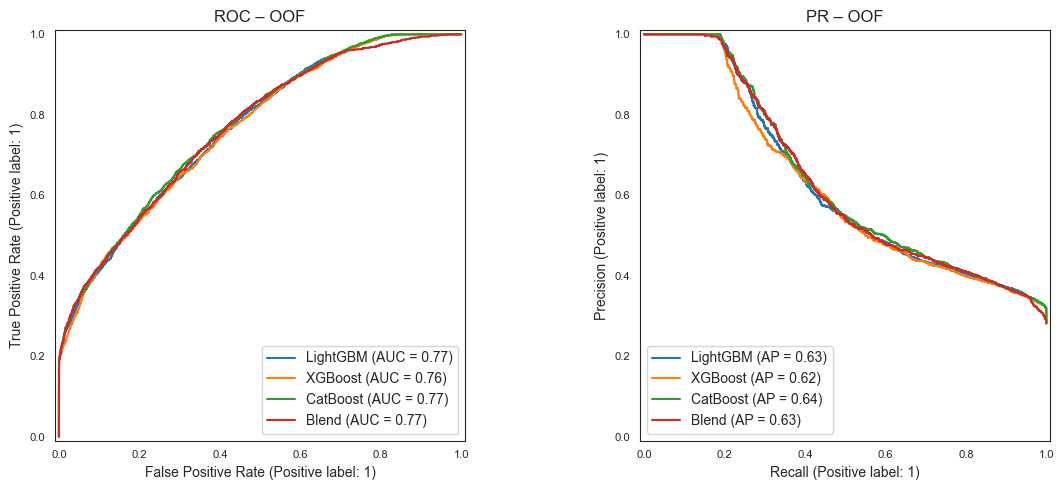

In [26]:
# ------------------------------------------------------------------
# 可视化 – ROC & PR 曲线
# ------------------------------------------------------------------
os.makedirs('figs', exist_ok=True)
save = lambda name: plt.savefig(f'figs/{name}.png', dpi=300, bbox_inches='tight')

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# ROC
for prob, label in [(oof_lgb, 'LightGBM'), (oof_xgb, 'XGBoost'), (oof_cat, 'CatBoost'), (oof_blend, 'Blend')]:
    RocCurveDisplay.from_predictions(y, prob, name=label, ax=ax[0])
ax[0].set_title('ROC – OOF')

# PR
for prob, label in [(oof_lgb, 'LightGBM'), (oof_xgb, 'XGBoost'), (oof_cat, 'CatBoost'), (oof_blend, 'Blend')]:
    PrecisionRecallDisplay.from_predictions(y, prob, name=label, ax=ax[1])
ax[1].set_title('PR – OOF')

plt.tight_layout()
save('roc_pr')
plt.show()  # 显示图片
plt.close()

正在绘制 ROC/PR 曲线...


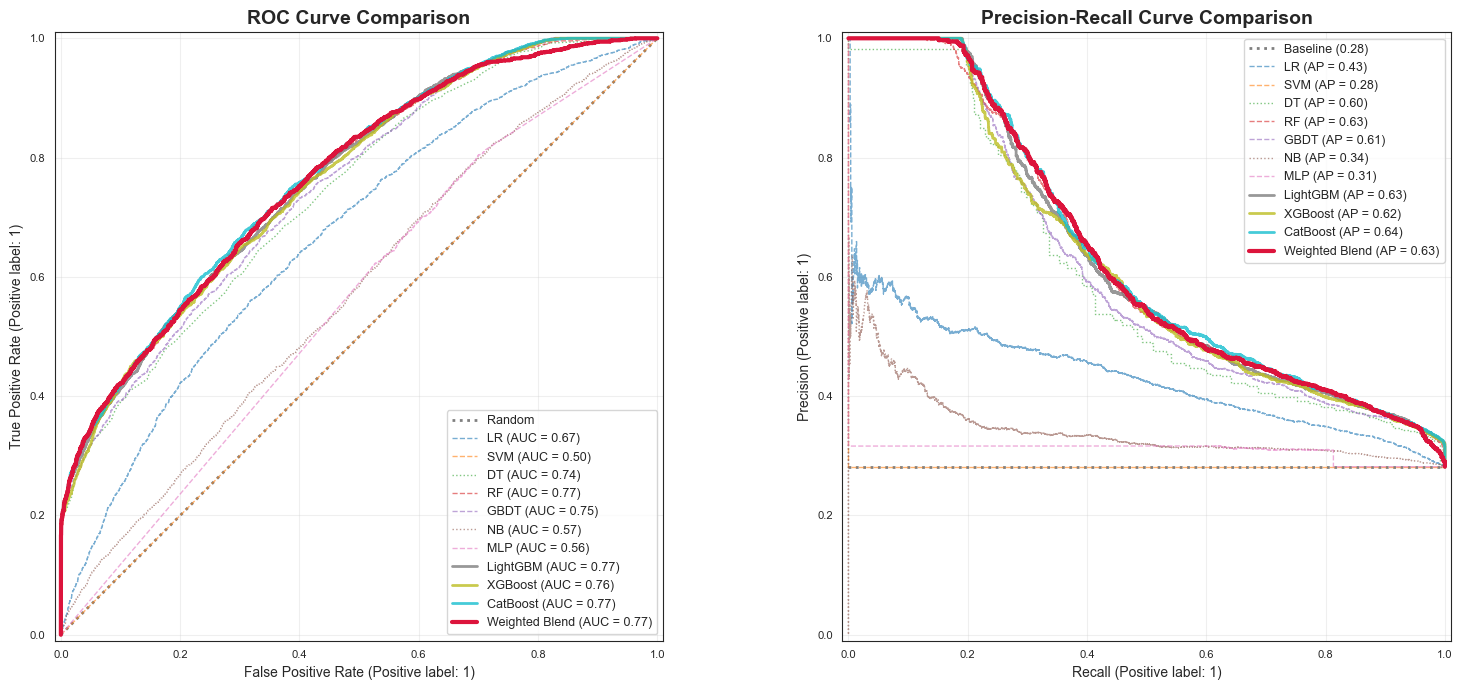

In [27]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
import os

plot_data = [
    # --- 基础模型 (Sklearn) ---
    (oof_lr,   'LR',   {'lw': 1, 'alpha': 0.6, 'linestyle': '--'}),
    (oof_svm,  'SVM',  {'lw': 1, 'alpha': 0.6, 'linestyle': '--'}),
    (oof_dt,   'DT',   {'lw': 1, 'alpha': 0.6, 'linestyle': ':'}),
    (oof_rf,   'RF',   {'lw': 1, 'alpha': 0.6, 'linestyle': '--'}),
    (oof_gbdt, 'GBDT', {'lw': 1, 'alpha': 0.6, 'linestyle': '--'}),
    (oof_nb,   'NB',   {'lw': 1, 'alpha': 0.6, 'linestyle': ':'}),
    (oof_mlp,  'MLP',  {'lw': 1, 'alpha': 0.6, 'linestyle': '--'}),
    
    # --- 提升树模型 (Boosting) ---
    (oof_lgb,  'LightGBM', {'lw': 2, 'alpha': 0.8}),
    (oof_xgb,  'XGBoost',  {'lw': 2, 'alpha': 0.8}),
    (oof_cat,  'CatBoost', {'lw': 2, 'alpha': 0.8}),
    
    # --- 融合模型 (Ensemble) ---
    (oof_blend, 'Weighted Blend', {'lw': 3, 'alpha': 1.0, 'color': 'crimson', 'zorder': 10}),
    # (stack_oof_pred, 'Stacking', {'lw': 3, 'alpha': 1.0, 'color': 'navy', 'zorder': 10}),
]

# 2. 设置绘图环境
os.makedirs('figs', exist_ok=True)
save = lambda name: plt.savefig(f'figs/{name}.png', dpi=300, bbox_inches='tight')

# 创建画布
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# 3. 循环绘图
print("正在绘制 ROC/PR 曲线...")

# --- ROC 曲线 ---
ax[0].plot([0, 1], [0, 1], linestyle=':', lw=2, color='gray', label='Random') # 对角线
for prob, label, kwargs in plot_data:
    RocCurveDisplay.from_predictions(
        y, prob, 
        name=label, 
        ax=ax[0], 
        plot_chance_level=False, # 手动画了对角线，这里关掉
        **kwargs
    )

ax[0].set_title('ROC Curve Comparison', fontsize=14, fontweight='bold')
ax[0].grid(True, alpha=0.3)
ax[0].legend(loc='lower right', fontsize=9)

# --- PR 曲线 ---
# 计算基准线 (Positive Rate)
baseline = y.sum() / len(y)
ax[1].plot([0, 1], [baseline, baseline], linestyle=':', lw=2, color='gray', label=f'Baseline ({baseline:.2f})')

for prob, label, kwargs in plot_data:
    PrecisionRecallDisplay.from_predictions(
        y, prob, 
        name=label, 
        ax=ax[1], 
        plot_chance_level=False,
        **kwargs
    )

ax[1].set_title('Precision-Recall Curve Comparison', fontsize=14, fontweight='bold')
ax[1].grid(True, alpha=0.3)
ax[1].legend(loc='upper right', fontsize=9)

# 4. 保存与展示
plt.tight_layout()
save('roc_pr_all_models')
plt.show()
plt.close()

正在筛选最佳单模型...

>>> 最佳模型: 【CatBoost】
>>> 最佳 F1 : 0.5495
>>> 最佳阈值: 0.3179


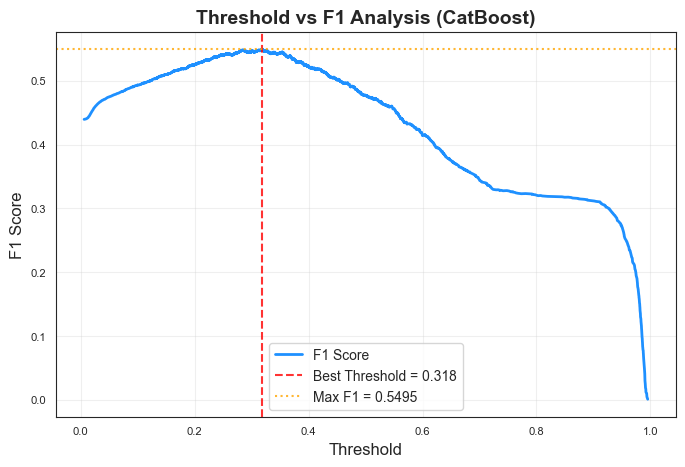

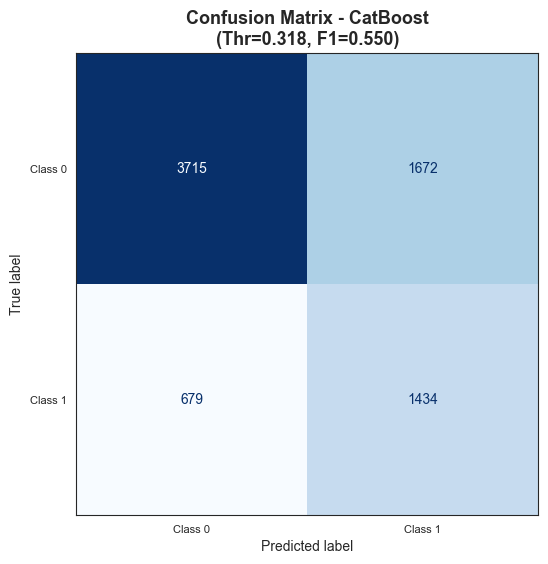

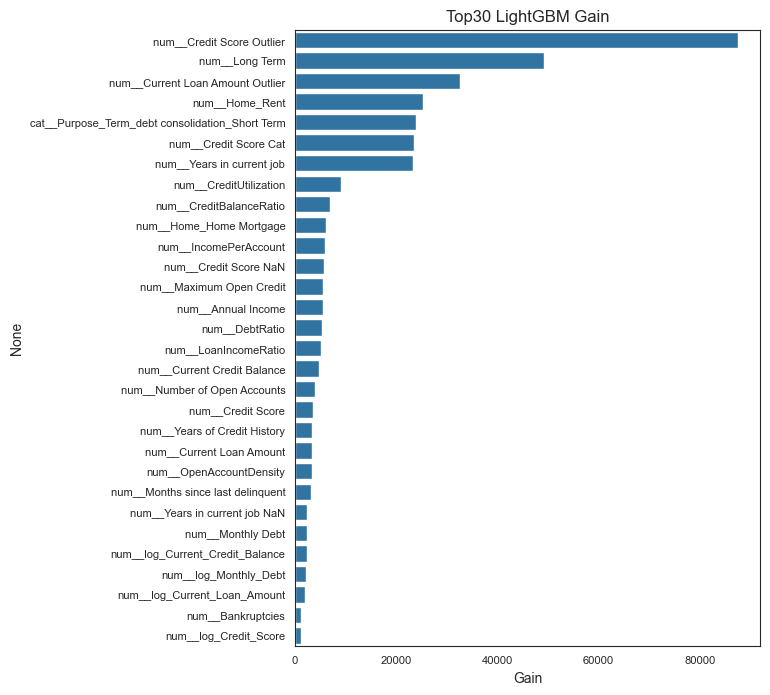

In [32]:
# ======================================================
# 1. 筛选最好单模
# ======================================================
candidates = {
    'Logistic Regression': oof_lr,
    'SVM': oof_svm,
    'Decision Tree': oof_dt,
    'Random Forest': oof_rf,
    'GBDT': oof_gbdt,
    'Naive Bayes': oof_nb,
    'MLP': oof_mlp,
    'LightGBM': oof_lgb,
    'XGBoost': oof_xgb,
    'CatBoost': oof_cat
}

best_model_name = None
best_model_oof = None
global_best_f1 = -1
global_best_thr = -1

print("正在筛选最佳单模型...")
for name, oof_pred in candidates.items():
    # 计算该模型下的最佳阈值和F1
    p, r, t = precision_recall_curve(y, oof_pred)
    f1_scores = 2 * (p * r) / (p + r + 1e-8)

    idx = np.argmax(f1_scores)
    current_max_f1 = f1_scores[idx]
    
    current_best_thr = t[idx] if idx < len(t) else t[-1]
    
    if current_max_f1 > global_best_f1:
        global_best_f1 = current_max_f1
        global_best_thr = current_best_thr
        best_model_name = name
        best_model_oof = oof_pred

print(f"\n>>> 最佳模型: 【{best_model_name}】")
print(f">>> 最佳 F1 : {global_best_f1:.4f}")
print(f">>> 最佳阈值: {global_best_thr:.4f}")

# ======================================================
# 2. 绘制最佳单模型的 阈值-F1 曲线
# ======================================================
os.makedirs('figs', exist_ok=True)
save = lambda name: plt.savefig(f'figs/{name}.png', dpi=300, bbox_inches='tight')

# 重新计算一遍胜出模型的数据用于绘图
precision, recall, thresholds = precision_recall_curve(y, best_model_oof)
f1s = 2 * (precision * recall) / (precision + recall + 1e-8)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1s[:-1], label='F1 Score', color='dodgerblue', linewidth=2)
plt.axvline(global_best_thr, color='red', linestyle='--', alpha=0.8, 
            label=f'Best Threshold = {global_best_thr:.3f}')
plt.axhline(global_best_f1, color='orange', linestyle=':', alpha=0.8, 
            label=f'Max F1 = {global_best_f1:.4f}')

plt.xlabel('Threshold', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.title(f'Threshold vs F1 Analysis ({best_model_name})', fontsize=14, fontweight='bold')
plt.legend(loc='lower center')
plt.grid(True, alpha=0.3)

save(f'threshold_f1_{best_model_name.replace(" ", "_")}') # 文件名带上模型名
plt.show()
plt.close()

# ======================================================
# 3. 绘制最佳单模型的 混淆矩阵
# ======================================================
# 使用最佳阈值将概率转为 0/1
pred_best_binary = (best_model_oof >= global_best_thr).astype(int)

cm = confusion_matrix(y, pred_best_binary)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d', colorbar=False)

ax.set_title(f'Confusion Matrix - {best_model_name}\n(Thr={global_best_thr:.3f}, F1={global_best_f1:.3f})', 
             fontsize=13, fontweight='bold')

save(f'confusion_matrix_{best_model_name.replace(" ", "_")}')
plt.show()
plt.close()


# ========== 特征重要性（LightGBM示例） ==========
lgb_booster = m_lgb.booster_ if hasattr(m_lgb, 'booster_') else m_lgb
importance = lgb_booster.feature_importance(importance_type='gain')
feat_names = preprocess.get_feature_names_out()
imp_df = (pd.Series(importance, index=feat_names)
            .sort_values(ascending=False).head(30))
plt.figure(figsize=(6,8))
sns.barplot(x=imp_df.values, y=imp_df.index)
plt.title('Top30 LightGBM Gain'); plt.xlabel('Gain')
save('lgb_importance')
plt.show()  # 显示图片
plt.close()

>>> SHAP 解释性（最佳模型catboost代表）


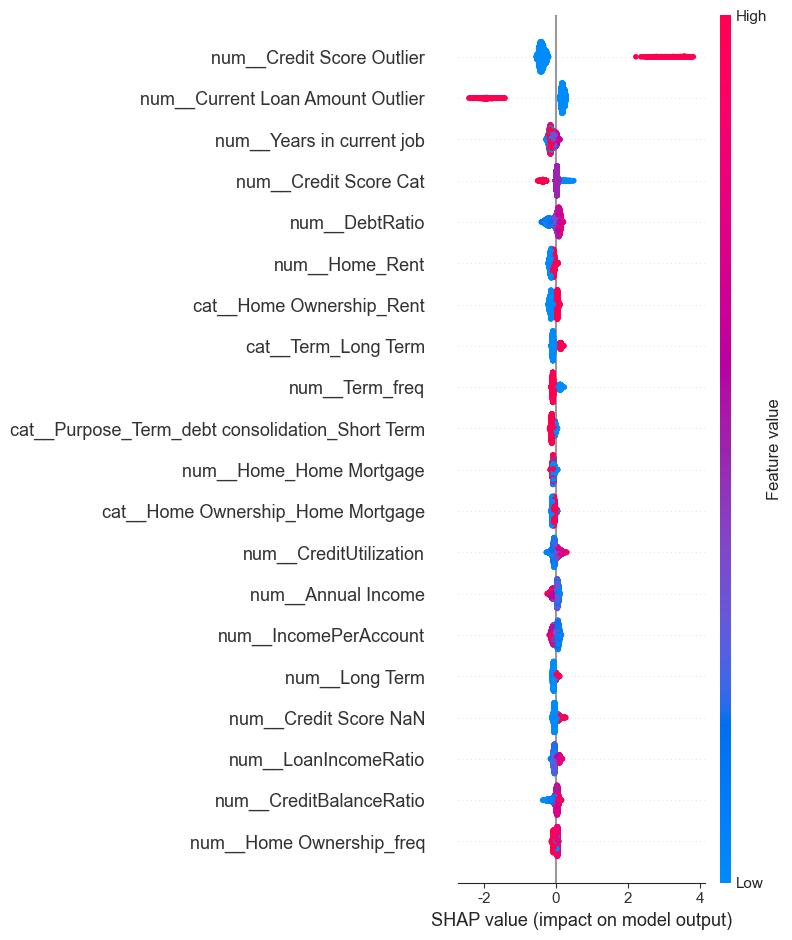

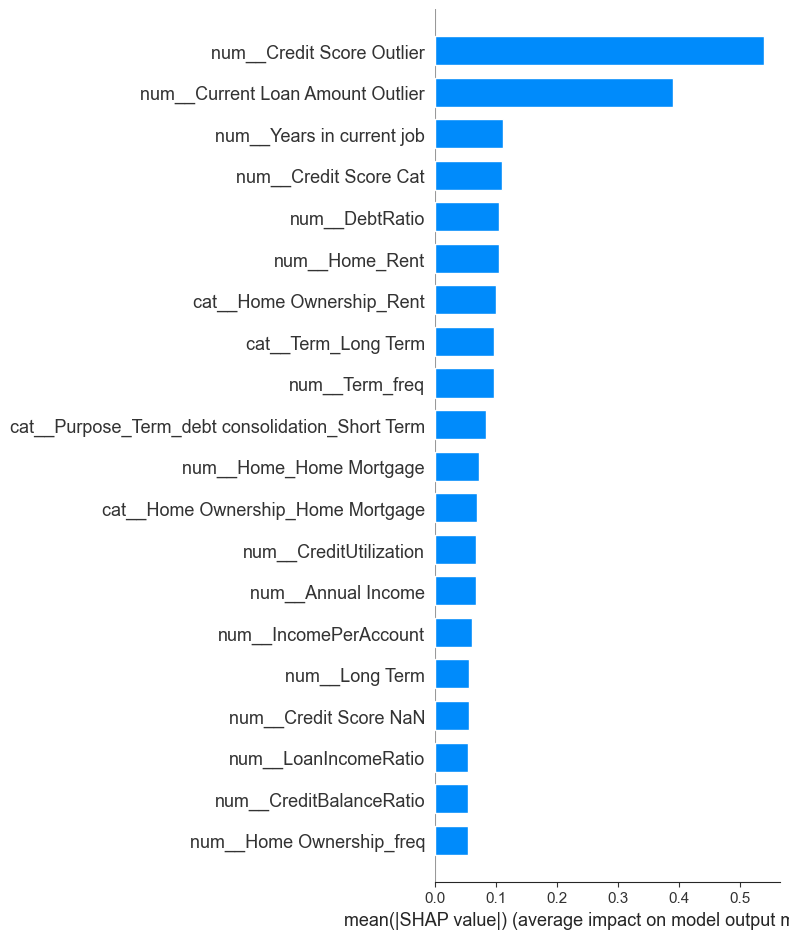

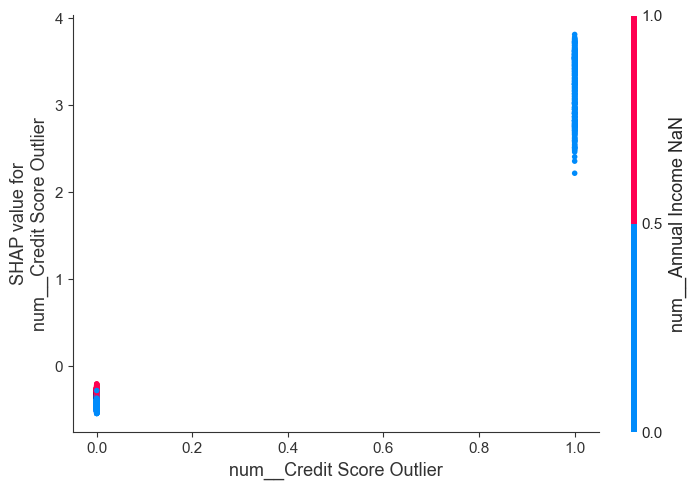

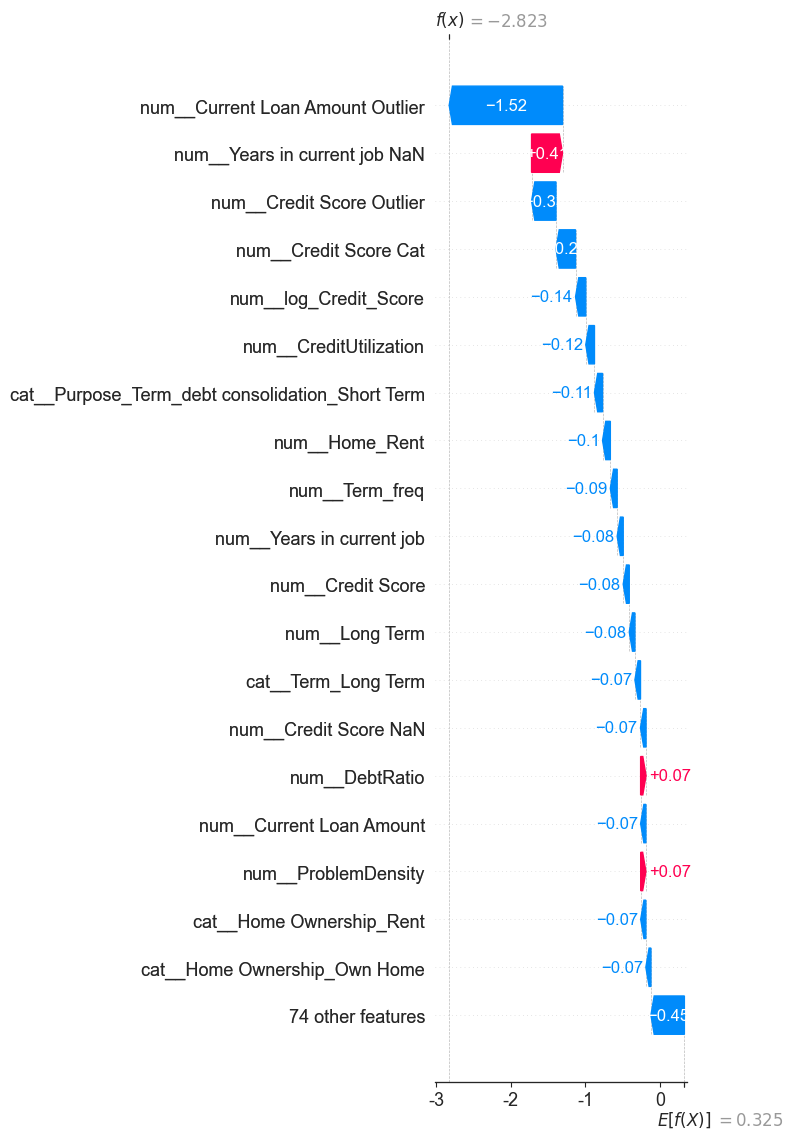

In [ ]:
# ------------------------------------------------------------------
# SHAP 汇总（用最佳模型代表）
# ------------------------------------------------------------------
print('>>> SHAP 解释性（最佳模型Catboost代表）')
explainer = shap.TreeExplainer(m_cat)          # 也可用 m_xgb / m_lgb
sample_num = None  # 或者可以取 2k 样本加速
shap_values = explainer.shap_values(X_full[:sample_num])

# 摘要图
shap.summary_plot(shap_values, X_full[:sample_num],
                  feature_names=preprocess.get_feature_names_out(), show=False)
plt.tight_layout()
plt.savefig("figs/shap_summary.png", dpi=300)
save('shap_summary')
plt.show()  # 显示图片
plt.close()

# 条形图
shap.summary_plot(shap_values, X_full[:sample_num],
                  feature_names=preprocess.get_feature_names_out(),
                  plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("figs/shap_bar.png", dpi=300)
save('shap_bar')
plt.show()  # 显示图片
plt.close()

# ====== 2. SHAP 依赖图（以最重要特征为例） ======
top_feat = np.abs(shap_values).mean(0).argmax()  # 最重要特征索引
shap.dependence_plot(top_feat, shap_values, X_full[:sample_num],
                     feature_names=preprocess.get_feature_names_out(), show=False)
plt.tight_layout()
plt.savefig("figs/shap_dependence.png", dpi=300)
save('shap_dependence')
plt.show()  # 显示图片
plt.close()

# ====== 3. SHAP 瀑布图（单样本示例） ======
sample_idx = 0  # 可换任意样本
shap.waterfall_plot(
    shap.Explanation(values=shap_values[sample_idx],
                     base_values=explainer.expected_value,
                     feature_names=preprocess.get_feature_names_out()),
    max_display=20, show=False)
plt.tight_layout()
plt.savefig("figs/shap_waterfall.png", dpi=300)
save('shap_waterfall')
plt.show()  # 显示图片
plt.close()